[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/probability_statistics/10_bayesian_inference/first_principles.ipynb)

# Module 10 — Bayesian Inference

## 1. Why This Module Exists

Two questions look similar but are not: "how likely are these data if the parameter is $\theta$?" and "how plausible is $\theta$ now that I have seen these data?" The first is the likelihood and is answered by the model. The second requires a probability distribution *over parameters*, and the only coherent way to obtain one is Bayes' theorem:

$$
p(\theta \mid x) = \frac{p(x \mid \theta)\,p(\theta)}{p(x)}, \qquad p(x) = \int p(x\mid\theta)\,p(\theta)\,d\theta .
$$

The prior $p(\theta)$ is the price of admission — a model that only describes $x$ cannot by itself produce a distribution over $\theta$. In exchange you receive an object that answers every downstream question directly: point estimates are posterior functionals, intervals are posterior probabilities, predictions are posterior averages, and decisions minimize posterior expected loss.

The mechanics are best read in log space, where multiplication becomes addition:

$$
\ln p(\theta\mid x) = \underbrace{\ell(\theta)}_{\text{evidence from data}} + \underbrace{\ln p(\theta)}_{\text{evidence from before}} - \underbrace{\ln p(x)}_{\text{constant in } \theta} .
$$

Because $\ell$ accumulates one term per observation while $\ln p(\theta)$ is fixed, the data eventually dominate; the prior matters exactly in proportion to how little data you have. Theorem 4.10 and Theorem 4.11 make that statement quantitative.

**Why the update rule is forced.** Suppose you want to revise beliefs about $\theta$ upon seeing $x$ and you insist on two properties: the answer depends only on the observed $x$ (not on data you might have seen), and beliefs about compound events obey the product and sum rules of probability. Cox's consistency axioms and de Finetti's Dutch-book argument both conclude that the update must be

$$
\text{posterior} \ \propto\ \text{likelihood}\times\text{prior} .
$$

Any other rule admits a set of bets that loses money with certainty. This is why Bayes' rule is not one estimation technique among many but the unique coherent bookkeeping for uncertainty — the same status the sum-to-one axiom has.

**Why it scales.** The update is *sequential*: splitting data into $x_{1:m}$ and $x_{m+1:n}$ and processing the halves in either order gives the identical posterior (Theorem 4.1(b)). Kalman filters, online learning, and streaming A/B tests all exploit this, and it is a theorem rather than a convention.

**What it costs.** The evidence $p(x)$ is an integral over the whole parameter space, and outside a handful of families it has no closed form. Everything computational in this module — conjugacy, Laplace, MCMC, variational inference — is a strategy for never having to evaluate it, or for evaluating it only once.

## 2. Intuition

### The prior is a pile of pseudo-observations

Abstract priors become concrete inside conjugate families, where the posterior stays in the same family and updating amounts to adding counts. A $\text{Beta}(\alpha,\beta)$ prior for a coin behaves exactly like $\alpha$ prior heads and $\beta$ prior tails:

$$
\text{Beta}(\alpha,\beta) \ +\ (k \text{ heads},\ n-k \text{ tails}) \ \longrightarrow\ \text{Beta}(\alpha+k,\ \beta+n-k) .
$$

Its mean, $\frac{\alpha+k}{\alpha+\beta+n}$, is a weighted average of the prior mean and the sample proportion, with weights $\frac{\alpha+\beta}{\alpha+\beta+n}$ and $\frac{n}{\alpha+\beta+n}$. The quantity $\alpha+\beta$ is the *prior sample size*: it says how many observations of evidence the prior is worth. Choosing a prior then becomes an answerable engineering question — how much data would I need before I abandoned my current belief? — rather than a philosophical one.

### Uncertainty must be propagated, not collapsed

A trained model that reports $p(\tilde x\mid\hat\theta)$ is pretending $\hat\theta$ is exactly right. The Bayesian alternative averages over what $\theta$ could be, $p(\tilde x\mid x) = \int p(\tilde x\mid\theta)\,p(\theta\mid x)\,d\theta$, and the result is strictly wider by the law of total variance (Theorem 4.5):

$$
\operatorname{Var}\left(\tilde x\mid x\right) = \underbrace{E\left[\operatorname{Var}(\tilde x\mid\theta)\,\middle|\,x\right]}_{\text{aleatoric: irreducible noise}} + \underbrace{\operatorname{Var}\left(E[\tilde x\mid\theta]\,\middle|\,x\right)}_{\text{epistemic: parameter uncertainty}} .
$$

The second term is exactly what plug-in prediction discards, and it is the term that shrinks with more data. The split is the mathematical statement of the difference between "the world is noisy" and "I do not know the world yet" — the basis of active learning, exploration bonuses, and out-of-distribution detection.

### Borrowing strength across groups

When many similar units are measured — hospitals, schools, ad campaigns, batters — a prior shared across units is itself learned from the data. A noisy unit is then pulled toward the population mean and a well-measured unit is left alone, automatically and in exactly the proportion the two variances dictate (Theorem 4.6). Nothing about this is a heuristic; it falls out of a two-level probability model.

The figure below is the whole module in one panel: a $\text{Beta}(2,2)$ prior meets Bernoulli data generated at rate $0.3$, and the posterior is drawn after $n = 0, 5, 20, 200$ observations. Watch three things — the posterior narrows, its centre migrates from the prior mean $0.5$ toward the truth, and the prior's influence on the centre becomes invisible long before the width stops shrinking.

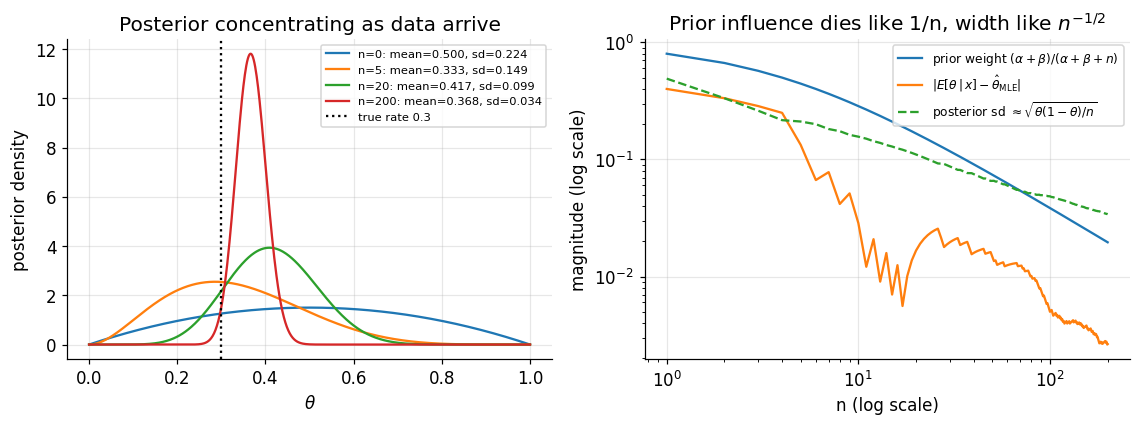

posterior after n=200: Beta(75, 129)
posterior mean: 0.36764705882352944
MLE           : 0.365


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy import stats, integrate, special, optimize

# Beta-Binomial conjugate update: prior -> posterior as data arrive. True rate 0.3.
true_p, alpha0, beta0 = 0.3, 2.0, 2.0
flips = rng.binomial(1, true_p, size=200)
grid = np.linspace(0.0, 1.0, 601)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
for n in [0, 5, 20, 200]:
    k = int(flips[:n].sum())
    a_n, b_n = alpha0 + k, beta0 + (n - k)
    axes[0].plot(grid, stats.beta.pdf(grid, a_n, b_n),
                 label=f"n={n}: mean={a_n/(a_n+b_n):.3f}, sd={np.sqrt(a_n*b_n/((a_n+b_n)**2*(a_n+b_n+1))):.3f}")
axes[0].axvline(true_p, color="k", ls=":", label="true rate 0.3")
axes[0].set_xlabel(r"$\theta$")
axes[0].set_ylabel("posterior density")
axes[0].set_title("Posterior concentrating as data arrive")
axes[0].legend(fontsize=7.5)

# The two components of the posterior mean: prior weight and data weight.
ns = np.arange(1, 201)
ks = np.cumsum(flips)[:200]
prior_weight = (alpha0 + beta0) / (alpha0 + beta0 + ns)
post_mean = (alpha0 + ks) / (alpha0 + beta0 + ns)
axes[1].plot(ns, prior_weight, label=r"prior weight $(\alpha+\beta)/(\alpha+\beta+n)$")
axes[1].plot(ns, np.abs(post_mean - ks / ns), label=r"$|E[\theta\,|\,x] - \hat\theta_{\rm MLE}|$")
axes[1].plot(ns, np.sqrt(post_mean * (1 - post_mean) / ns), ls="--", label=r"posterior sd $\approx \sqrt{\theta(1-\theta)/n}$")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("n (log scale)")
axes[1].set_ylabel("magnitude (log scale)")
axes[1].set_title("Prior influence dies like 1/n, width like $n^{-1/2}$")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print("posterior after n=200:", f"Beta({alpha0 + flips.sum():.0f}, {beta0 + 200 - flips.sum():.0f})")
print("posterior mean:", (alpha0 + flips.sum()) / (alpha0 + beta0 + 200))
print("MLE           :", flips.sum() / 200)

The left panel shows the mechanism: a $\text{Beta}(2,2)$ prior worth four pseudo-observations is overwhelmed within a few dozen real ones. The right panel separates the two rates that Theorem 4.10 and Theorem 4.11 predict and Section 7 measures: the gap between the posterior mean and the MLE decays like $1/n$ (the prior's contribution), while the posterior width decays only like $n^{-1/2}$. The prior therefore stops mattering an order of magnitude faster than the data stop mattering.

## 3. Definitions

### Definition 3.1 (Prior, likelihood, posterior, evidence)

Let $\theta$ take values in $\Theta \subseteq \mathbb{R}^d$ with **prior** density $p(\theta)$ with respect to a dominating measure, and let the data $x$ have conditional density $p(x\mid\theta)$, the **likelihood** when read as a function of $\theta$. The **evidence** (or marginal likelihood) is

$$
p(x) = \int_{\Theta} p(x\mid\theta)\,p(\theta)\,d\theta ,
$$

and wherever $p(x)\gt0$ the **posterior** is $p(\theta\mid x) = p(x\mid\theta)p(\theta)/p(x)$.

### Definition 3.2 (Posterior predictive)

For new data $\tilde x$ conditionally independent of $x$ given $\theta$,

$$
p(\tilde x\mid x) = \int_\Theta p(\tilde x\mid\theta)\,p(\theta\mid x)\,d\theta .
$$

### Definition 3.3 (Credible set, HPD region)

A set $C \subseteq \Theta$ is a $(1-\alpha)$ **credible set** if $P(\theta\in C\mid x) = \int_C p(\theta\mid x)\,d\theta = 1-\alpha$. The **highest posterior density** region is the credible set of the form $\{\theta : p(\theta\mid x) \ge c\}$ with $c$ chosen to reach level $1-\alpha$; among all $(1-\alpha)$ credible sets it has the smallest Lebesgue measure.

### Definition 3.4 (Conjugate family)

A family $\mathcal{P}$ of priors is **conjugate** to a likelihood $p(x\mid\theta)$ if $p(\theta)\in\mathcal{P}$ implies $p(\theta\mid x)\in\mathcal{P}$ for every $x$ with $p(x)\gt0$.

### Definition 3.5 (Exponential family and its conjugate prior)

A family is a $k$-parameter **exponential family** in natural form if $p(x\mid\eta) = h(x)\exp\left(\eta^{\top}T(x) - A(\eta)\right)$ with natural parameter $\eta\in\mathcal{H}$, sufficient statistic $T$, and log-partition $A(\eta) = \ln\int h(x)e^{\eta^{\top}T(x)}dx$. Its **canonical conjugate prior** is the two-hyperparameter family

$$
p(\eta\mid\chi,\nu) \ \propto\ \exp\left(\eta^{\top}\chi - \nu A(\eta)\right), \qquad (\chi,\nu)\in\mathbb{R}^k\times(0,\infty) ,
$$

restricted to $(\chi,\nu)$ for which the right-hand side is integrable over $\mathcal{H}$.

### Definition 3.6 (Jeffreys prior)

$p_J(\theta) \propto \sqrt{\det I(\theta)}$, where $I(\theta) = -E_\theta\left[\nabla^2_\theta \ln p(x\mid\theta)\right]$ is the Fisher information matrix of one observation.

### Definition 3.7 (Loss, posterior expected loss, Bayes action)

A **loss** is a measurable $L : \Theta\times\mathcal{A}\to[0,\infty)$ on parameters and actions. The **posterior expected loss** of an action $a$ is $\rho(a) = E\left[L(\theta,a)\mid x\right]$, and a **Bayes action** is any $a^\star \in \operatorname{argmin}_{a\in\mathcal A}\rho(a)$.

### Definition 3.8 (Bayes factor)

For models $M_1, M_2$ with evidences $p(x\mid M_1), p(x\mid M_2)$,

$$
\operatorname{BF}_{12} = \frac{p(x\mid M_1)}{p(x\mid M_2)}, \qquad \frac{P(M_1\mid x)}{P(M_2\mid x)} = \operatorname{BF}_{12}\cdot\frac{P(M_1)}{P(M_2)} .
$$

### Definition 3.9 (Evidence lower bound)

For a density $q$ on $\Theta$ whose support contains that of the posterior, the **ELBO** is

$$
\mathcal{L}(q) = E_q\left[\ln p(x,\theta)\right] - E_q\left[\ln q(\theta)\right] .
$$

### Definition 3.10 (Hierarchical / multilevel model)

With group index $j=1,\ldots,J$, per-group data $y_j$, per-group parameter $\theta_j$, and a shared hyperparameter $\phi$:

$$
\phi \sim p(\phi), \qquad \theta_j \mid \phi \ \overset{\text{iid}}{\sim}\ p(\theta_j\mid\phi), \qquad y_j \mid \theta_j \ \sim\ p(y_j\mid\theta_j) .
$$

The groups are conditionally independent given $\phi$ but *marginally* dependent: observing $y_1$ updates $\phi$, which shifts every other group's prior. That dependence is the mechanism behind partial pooling.

### Definition 3.11 (Transition kernel, detailed balance, full conditional)

A **transition kernel** $P(\theta\to\cdot)$ is a Markov chain's one-step conditional law. It satisfies **detailed balance** with respect to a density $\pi$ if $\pi(\theta)P(\theta\to\theta') = \pi(\theta')P(\theta'\to\theta)$ for all $\theta,\theta'$. For $\theta = (\theta_1,\ldots,\theta_d)$ the **full conditional** of coordinate $k$ is $\pi(\theta_k\mid\theta_{-k})$, where $\theta_{-k}$ collects the other coordinates. A model has **conditional conjugacy** if every full conditional lies in a family from which direct sampling is possible.

### Definition 3.12 (Total variation distance)

For probability measures $P, Q$ on a common space, $\lVert P - Q\rVert_{\mathrm{TV}} = \sup_A \vert P(A) - Q(A)\vert$; when both have densities $p,q$ this equals $\tfrac12\int\vert p - q\vert$.

## 4. Main Results

### Theorem 4.1 (Bayes' theorem for densities, and sequential consistency)

Let $(\theta,x)$ have a joint density with respect to a product dominating measure, with prior $p(\theta)$ and likelihood $p(x\mid\theta)$, and suppose $p(x) = \int p(x\mid\theta)p(\theta)\,d\theta$ is finite and strictly positive at the observed $x$. Then

$$
\boxed{\ p(\theta\mid x) = \frac{p(x\mid\theta)\,p(\theta)}{p(x)}\ }
$$

and, if in addition $x_{1:n}$ are conditionally independent given $\theta$, then for every $1\le m\lt n$

$$
p\left(\theta\mid x_{1:n}\right) \ \propto\ p\left(x_{m+1:n}\mid\theta\right)\,p\left(\theta\mid x_{1:m}\right) .
$$

*Why each hypothesis is needed.* A joint density is what makes the two factorizations of $p(\theta,x)$ available at all — without it, conditioning must be defined through regular conditional probabilities and the ratio may fail to be a density. Finiteness of $p(x)$ is what makes the posterior normalizable, and is exactly what an improper prior can destroy. Strict positivity of $p(x)$ excludes data the model calls impossible, where the ratio is $0/0$. Conditional independence is what lets the likelihood factor into batches; without it the second display is false, and a filter must insert a prediction step between updates.

**Interpretation.** The boxed identity says that all evidence enters through the likelihood and all prior knowledge through $p(\theta)$, with $p(x)$ a $\theta$-free constant. The consequence is operational: any algorithm that needs only ratios $p(\theta_1\mid x)/p(\theta_2\mid x)$ — optimization, Metropolis–Hastings, importance weighting — never has to compute the intractable integral. The second display upgrades "yesterday's posterior is today's prior" from slogan to theorem, so batch, streaming, and sharded inference agree exactly.

### Theorem 4.2 (Exponential-family conjugacy)

Let $p(x\mid\eta) = h(x)\exp\left(\eta^{\top}T(x)-A(\eta)\right)$ be an exponential family (Definition 3.5) and let the prior be $p(\eta\mid\chi,\nu)\propto\exp\left(\eta^{\top}\chi-\nu A(\eta)\right)$, assumed integrable over the natural parameter space $\mathcal{H}$. Then for i.i.d. $x_{1:n}$ the posterior is in the same family with

$$
\boxed{\ (\chi,\nu)\ \longmapsto\ \left(\chi + \sum_{i=1}^n T(x_i),\ \ \nu + n\right)\ }
$$

*Why each hypothesis is needed.* The exponential-family form is what makes the likelihood's $\eta$-dependence linear in $T(x)$ and $A(\eta)$, so that prior and likelihood exponents add; for a non-exponential family (e.g. $\text{Unif}(0,\theta)$, whose support depends on $\theta$) no finite-dimensional conjugate family exists. Integrability of the prior is what makes it a prior at all — for many families some $(\chi,\nu)$ give a non-integrable expression, and the corresponding "prior" is improper. The i.i.d. assumption is what makes the sufficient statistics add.

**Interpretation.** The hyperparameters are pseudo-data: $\chi$ is a pseudo-sufficient-statistic and $\nu$ a pseudo-count, so "how strong is my prior?" has the literal answer "$\nu$ observations". Updating costs $O(n)$ arithmetic and no integration, which is why conjugate models remain the backbone of streaming systems, Gibbs samplers, and the local updates inside variational inference.

### Corollary 4.3 (The four workhorse conjugate pairs)

| Likelihood | Prior | Posterior |
|---|---|---|
| $\text{Binomial}(n,p)$, $k$ successes | $\text{Beta}(\alpha,\beta)$ | $\text{Beta}(\alpha+k,\ \beta+n-k)$ |
| $\mathcal{N}(\mu,\sigma^2)$, $\sigma^2$ known | $\mathcal{N}(\mu_0,\tau_0^2)$ | $\mathcal{N}(\mu_n,\tau_n^2)$, $\tau_n^{-2}=\tau_0^{-2}+n\sigma^{-2}$ |
| $\text{Poisson}(\lambda)$, exposure $n$ | $\text{Gamma}(a,b)$ | $\text{Gamma}\left(a+\sum_i x_i,\ b+n\right)$ |
| $\text{Categorical}(\pi)$, counts $n_k$ | $\text{Dirichlet}(\alpha)$ | $\text{Dirichlet}(\alpha+n)$ |

### Theorem 4.4 (Bayes estimators are determined by the loss)

Let $\theta$ be real-valued with posterior $p(\theta\mid x)$.

- (a) If $E\left[\theta^2\mid x\right]\lt\infty$, the unique minimizer of $\rho(a)=E\left[(\theta-a)^2\mid x\right]$ is the posterior mean, and $\rho(a^\star)=\operatorname{Var}(\theta\mid x)$.
- (b) If $E\left[\vert\theta\vert\mid x\right]\lt\infty$, every posterior median minimizes $\rho(a)=E\left[\vert\theta-a\vert\mid x\right]$.
- (c) For the asymmetric ("pinball" or newsvendor) loss $L(\theta,a)=c_o(a-\theta)_+ + c_u(\theta-a)_+$ with $c_o,c_u\gt0$, every $a^\star$ with $F(a^\star\mid x) = \frac{c_u}{c_o+c_u}$ is a minimizer.
- (d) If $p(\cdot\mid x)$ is continuous and bounded, then as $\epsilon\downarrow0$ the minimizers of $E\left[\mathbf{1}\{\vert\theta-a\vert\gt\epsilon\}\mid x\right]$ converge to the posterior mode (MAP).

$$
\boxed{\ \text{squared}\mapsto\text{mean},\quad \text{absolute}\mapsto\text{median},\quad \text{pinball}\mapsto\tfrac{c_u}{c_o+c_u}\text{-quantile},\quad 0\text{–}1\mapsto\text{mode}\ }
$$

*Why each hypothesis is needed.* A finite second moment is what makes $\rho$ finite in (a); a Cauchy posterior has no mean and no squared-loss Bayes action. A finite first moment plays the same role in (b). Positivity of both costs in (c) is what makes the target probability lie in $(0,1)$. Continuity and boundedness of the density in (d) is what makes $\int_{a-\epsilon}^{a+\epsilon}p \approx 2\epsilon\,p(a\mid x)$ legitimate; for a discrete or unbounded posterior the limit can fail, and this is why MAP misbehaves under reparameterization, which changes the density by a Jacobian.

**Interpretation.** Reporting "the estimate" is not a stylistic choice: the summary is a function of the loss you actually face. Symmetric unimodal posteriors hide this because mean, median, and mode coincide; skewed ones expose it, and asymmetric costs move the answer into the tail. Part (c) is why inventory, staffing, and latency-SLO decisions are quantile problems.

### Theorem 4.5 (Predictive variance decomposition)

Let $\tilde x$ be conditionally independent of $x$ given $\theta$, with $E\left[\tilde x^2\mid\theta\right]\lt\infty$ almost surely and $E\left[\tilde x^2\mid x\right]\lt\infty$. Then

$$
\boxed{\ \operatorname{Var}(\tilde x\mid x) = E\left[\operatorname{Var}(\tilde x\mid\theta)\ \middle|\ x\right] + \operatorname{Var}\left(E[\tilde x\mid\theta]\ \middle|\ x\right)\ }
$$

*Why each hypothesis is needed.* Conditional independence is what makes $E[\tilde x\mid\theta,x]=E[\tilde x\mid\theta]$, so the inner expectations do not secretly depend on $x$. The moment conditions are what make every term finite; without them the identity is a statement about undefined quantities.

**Interpretation.** The first term is *aleatoric* noise, irreducible no matter how much data you collect; the second is *epistemic*, and it is the term plug-in prediction sets to zero. Because the second term shrinks like $1/n$ while the first does not, plug-in prediction is asymptotically harmless and small-sample dangerous — precisely the regime in which it is most often used.

### Theorem 4.6 (Normal–Normal shrinkage and partial pooling)

In the two-level model of Definition 3.10 with $\theta_j\mid\mu,\tau^2\sim\mathcal{N}(\mu,\tau^2)$ and $y_j\mid\theta_j\sim\mathcal{N}(\theta_j,\sigma_j^2)$, where $\sigma_j^2\gt0$ is known and $\tau^2\gt0$,

$$
\boxed{\ E\left[\theta_j \mid y_j,\mu,\tau^2\right] = (1-B_j)\,y_j + B_j\,\mu, \qquad B_j = \frac{\sigma_j^2}{\sigma_j^2+\tau^2}\ }
$$

and, marginally over $\theta_j$, $\ y_j\mid\mu,\tau^2\sim\mathcal{N}\left(\mu,\ \sigma_j^2+\tau^2\right)$.

*Why each hypothesis is needed.* Known $\sigma_j^2$ is what makes the update a one-observation Normal–Normal step with no nuisance parameter; when $\sigma_j^2$ is estimated the shrinkage factor is random and empirical-Bayes intervals undercover. Strict positivity of $\tau^2$ is what keeps $B_j\lt1$; at $\tau^2=0$ the model degenerates to complete pooling and every group is assigned $\mu$ regardless of its data. Normality of both levels is what makes the posterior mean linear in $y_j$; with heavy-tailed group effects the posterior mean is a non-linear, outlier-robust function of $y_j$.

**Interpretation.** $B_j$ is the fraction of a group's total variance that is measurement noise, so a noisy group is pulled hard toward the population mean and a precise group barely moves. The marginal law is what makes the hyperparameters estimable: its likelihood in $(\mu,\tau^2)$ is what empirical Bayes maximizes, and what a fully Bayesian treatment puts a hyperprior on. This is the statistical content of multi-task learning, and the reason a batter with five at-bats is not projected to hit $.600$.

### Theorem 4.7 (ELBO identity)

Let $q$ be a density on $\Theta$ with $q \ll p(\cdot\mid x)$ and $E_q\left\vert\ln p(x,\theta)\right\vert\lt\infty$, $E_q\left\vert\ln q(\theta)\right\vert\lt\infty$. Then

$$
\boxed{\ \ln p(x) = \mathcal{L}(q) + D_{\mathrm{KL}}\left(q \parallel p(\cdot\mid x)\right)\ \ge\ \mathcal{L}(q)\ }
$$

with equality if and only if $q = p(\cdot\mid x)$ almost everywhere.

*Why each hypothesis is needed.* Absolute continuity $q\ll p(\cdot\mid x)$ is what keeps the KL divergence finite; a $q$ placing mass where the posterior has none makes both sides infinite and the identity vacuous. The two integrability conditions are what let the logarithm be split across the expectation without producing $\infty-\infty$.

**Interpretation.** Because $\ln p(x)$ is a constant fixed by the data, *maximizing the ELBO is exactly minimizing $D_{\mathrm{KL}}(q\parallel p(\cdot\mid x))$*: an integration problem has become an optimization problem, and the achieved gap is a computable measure of how wrong the approximation is. The direction of the divergence is not cosmetic — $q$ pays an unbounded penalty for putting mass where the posterior has none but no penalty for missing mass, so mean-field solutions are systematically too narrow. Section 7 measures that bias.

### Theorem 4.8 (Metropolis–Hastings correctness)

Let $\pi(\theta) = \tilde\pi(\theta)/Z$ be a target density known only through $\tilde\pi$, and let $q(\theta'\mid\theta)$ be a proposal density. The chain that proposes $\theta'\sim q(\cdot\mid\theta)$ and accepts with

$$
a\left(\theta\to\theta'\right) = \min\left\{1,\ \frac{\tilde{\pi}(\theta')\,q(\theta\mid\theta')}{\tilde{\pi}(\theta)\,q(\theta'\mid\theta)}\right\}
$$

satisfies detailed balance with respect to $\pi$, hence has $\pi$ as a stationary distribution. If the chain is additionally $\pi$-irreducible and aperiodic, then for every $\pi$-integrable $f$ and every starting point, $\frac1T\sum_{t\le T}f(\theta_t)\to E_\pi[f]$ almost surely.

$$
\boxed{\ \pi(\theta)\,q(\theta'\mid\theta)\,a(\theta\to\theta') = \pi(\theta')\,q(\theta\mid\theta')\,a(\theta'\to\theta), \qquad Z \text{ cancels}\ }
$$

*Why each hypothesis is needed.* Positivity of $\tilde\pi$ and $q$ on the region visited is what keeps the ratio defined. Irreducibility is what rules out a chain trapped in one mode of a multimodal posterior — stationarity alone does not imply the chain ever visits the rest of the space. Aperiodicity rules out deterministic cycling; the Metropolis rejection step supplies it automatically whenever rejection has positive probability.

**Interpretation.** Only the *ratio* $\tilde\pi(\theta')/\tilde\pi(\theta)$ appears, so the intractable evidence $Z=p(x)$ never has to be evaluated. That single cancellation is what makes Bayesian inference computable for models with no conjugate structure. The price is that convergence is asymptotic and unverifiable in finite time, which is why diagnostics ($\hat R$, effective sample size) are not optional.

### Corollary 4.9 (Gibbs sampling)

If the proposal for coordinate $k$ is its exact full conditional, $q(\theta'\mid\theta) = \pi\left(\theta_k'\mid\theta_{-k}\right)$ with $\theta'_{-k}=\theta_{-k}$, the acceptance ratio is identically $1$. Sweeping $k=1,\ldots,d$ therefore leaves $\pi$ invariant, and the sweep is a valid sampler whenever every full conditional can be drawn from directly — the conditional-conjugacy condition of Definition 3.11, which Theorem 4.2 supplies coordinate-by-coordinate inside a hierarchical model.

### Theorem 4.10 (Bernstein–von Mises; cited, not proved here)

Let $x_{1:n}$ be i.i.d. from $p(\cdot\mid\theta_0)$ with $\theta_0$ interior to $\Theta\subseteq\mathbb{R}^d$, suppose the model is differentiable in quadratic mean at $\theta_0$ with non-singular Fisher information $I(\theta_0)$, that for every $\varepsilon\gt0$ there is a test sequence separating $\theta_0$ from $\{\lVert\theta-\theta_0\rVert\ge\varepsilon\}$, and that the prior has a density that is continuous and strictly positive at $\theta_0$. Let $\Pi_n$ denote the posterior law of the *rescaled* parameter $\sqrt{n}\left(\theta-\hat\theta_n\right)$ for an efficient estimator $\hat\theta_n$. Then

$$
\left\lVert\, \Pi_n - \mathcal{N}\left(0,\ I(\theta_0)^{-1}\right)\,\right\rVert_{\mathrm{TV}} \ \xrightarrow{P}\ 0 .
$$

Reference: van der Vaart, *Asymptotic Statistics* (1998), §10.2, Theorem 10.1, p. 141.

*Why each hypothesis is needed.* Differentiability in quadratic mean is the local-asymptotic-normality condition that makes the log-likelihood ratio locally quadratic; it fails for $\text{Unif}(0,\theta)$, whose posterior converges at rate $n$ to a one-sided exponential law. Non-singular $I(\theta_0)$ is what makes the limit a proper Gaussian rather than a degenerate one. The testing condition is what forces the posterior to concentrate near $\theta_0$ rather than in a distant region the local expansion never sees. Continuity and positivity of the prior at $\theta_0$ is what makes the prior asymptotically constant on the $O(n^{-1/2})$ ball carrying the posterior mass; a prior vanishing near $\theta_0$ yields a posterior that never concentrates there (Cromwell's rule). Interiority of $\theta_0$ is what excludes boundary problems such as testing $\tau^2=0$ in a hierarchical model, and the whole statement is an asymptotic in $n$ with $d$ *fixed*.

**Interpretation.** Asymptotically the posterior forgets the prior and matches the sampling distribution of the MLE, so credible sets acquire correct frequentist coverage and posterior standard deviations become standard errors. The statement is about the rescaled parameter and about *measures*, not densities: total variation is a distance between laws, and the rescaling by $\sqrt n$ is what keeps the limit non-degenerate. The theorem is therefore also a map of where the two frameworks genuinely disagree — small $n$, boundaries, non-regular supports, and growing dimension.

### Theorem 4.11 (Bernstein–von Mises for the Gaussian location model, with an explicit rate)

Let $x_{1:n}$ be i.i.d. $\mathcal{N}(\theta_0,\sigma^2)$ with $\sigma^2\gt0$ known, and let the prior be $\theta\sim\mathcal{N}(\mu_0,\tau_0^2)$ with $0\lt\tau_0^2\lt\infty$. Write $\hat\theta_n=\bar x_n$, $I(\theta_0)=\sigma^{-2}$, $s_n^2 = \left[nI(\theta_0)\right]^{-1} = \sigma^2/n$, and let $\Pi_n$ be the exact posterior law of $\theta$. Then

$$
\boxed{\ \left\lVert \Pi_n - \mathcal{N}\left(\hat\theta_n,\ s_n^2\right)\right\rVert_{\mathrm{TV}} \ \le\ \sqrt{\tfrac12 K_n}, \qquad K_n \ \le\ \frac{\varepsilon_n^2}{4} + \frac{\sigma^2\left(\mu_0-\bar x_n\right)^2}{2\,n\,\tau_0^4}, \qquad \varepsilon_n = \frac{\sigma^2}{n\tau_0^2}\ }
$$

where $K_n = D_{\mathrm{KL}}\left(\Pi_n \parallel \mathcal{N}(\hat\theta_n, s_n^2)\right)$. Consequently $K_n = O_P(n^{-1})$ and the total-variation distance is $O_P\left(n^{-1/2}\right)$, so it tends to $0$ in probability.

*Why each hypothesis is needed.* Known $\sigma^2$ is what keeps the posterior exactly Gaussian, so the bound is an identity rather than an approximation; with $\sigma^2$ unknown the posterior is a $t$ law and an extra $O(n^{-1})$ term appears. $\tau_0^2\gt0$ is the positivity-of-the-prior hypothesis in its sharpest form: at $\tau_0^2=0$ the posterior is the point mass $\delta_{\mu_0}$ and the total-variation distance equals $1$ for every $n$ unless $\mu_0=\theta_0$. $\tau_0^2\lt\infty$ keeps the prior proper, so $\varepsilon_n$ and the mean gap are finite.

**Interpretation.** This is the full-strength special case of Theorem 4.10 that this module supports, and it is stronger than the cited theorem in two ways: it holds for every $n$, not asymptotically, and it names the constant. The bound decomposes prior influence into a variance mismatch of order $n^{-2}$ and a mean displacement of order $n^{-1}$, so the posterior *mean* forgets the prior at rate $1/n$ while the total-variation distance closes only at rate $n^{-1/2}$ — the two rates the figure in Section 2 draws and the code in Section 7 measures.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

**Part (a).** By the definition of a conditional density the joint factors two ways:

$$
p(\theta, x) = p(\theta\mid x)\,p(x) = p(x\mid\theta)\,p(\theta) .
$$

Both factorizations are valid because a joint density exists. Dividing by $p(x)\gt0$ gives $p(\theta\mid x) = p(x\mid\theta)p(\theta)/p(x)$. The denominator is forced by normalization: integrating the numerator over $\Theta$ and demanding $\int p(\theta\mid x)d\theta = 1$ yields $p(x) = \int p(x\mid\theta)p(\theta)d\theta$, which is finite by hypothesis. $\square$

**Part (b).** With conditional independence given $\theta$, $p(x_{1:n}\mid\theta) = p(x_{m+1:n}\mid\theta)\,p(x_{1:m}\mid\theta)$, so

$$
p\left(\theta\mid x_{1:n}\right) \ \propto\ p\left(x_{1:n}\mid\theta\right)p(\theta) = p\left(x_{m+1:n}\mid\theta\right)\underbrace{p\left(x_{1:m}\mid\theta\right)p(\theta)}_{\propto\ p(\theta\mid x_{1:m})} \ \propto\ p\left(x_{m+1:n}\mid\theta\right)\,p\left(\theta\mid x_{1:m}\right) .
$$

Both ends are densities in $\theta$; proportional densities that both integrate to $1$ are equal. $\blacksquare$

Because a product is invariant under regrouping and reordering, any partition of the data into batches, processed in any order, gives the same posterior.

### Proof 5.2 (of Theorem 4.2 and Corollary 4.3, Beta–Binomial row)

**General case.** For i.i.d. $x_{1:n}$ the likelihood is $\left(\prod_i h(x_i)\right)\exp\left(\eta^{\top}\sum_i T(x_i) - nA(\eta)\right)$. Multiplying by the prior and discarding every factor free of $\eta$,

$$
p\left(\eta\mid x_{1:n}\right) \ \propto\ \exp\left(\eta^{\top}\left[\chi + \sum_i T(x_i)\right] - \left[\nu + n\right]A(\eta)\right) ,
$$

which is the same functional form with hyperparameters $\left(\chi+\sum_i T(x_i),\ \nu+n\right)$. Integrability of the posterior follows because the exponent is the prior exponent evaluated at admissible hyperparameters whenever the data are finite and $A$ is convex on $\mathcal{H}$; a density is determined by its kernel, so the normalizer is fixed. $\square$

**Beta–Binomial instance.** With $p(p) \propto p^{\alpha-1}(1-p)^{\beta-1}$ and likelihood $\binom{n}{k}p^k(1-p)^{n-k}$,

$$
p(p\mid k)\ \propto\ p^{k}(1-p)^{n-k}\cdot p^{\alpha-1}(1-p)^{\beta-1} = p^{(\alpha+k)-1}(1-p)^{(\beta+n-k)-1} ,
$$

the kernel of $\text{Beta}(\alpha+k,\ \beta+n-k)$, so the normalizer is $1/B(\alpha+k,\beta+n-k)$. $\blacksquare$

With $a=\alpha+k$, $b=\beta+n-k$, $m=\alpha+\beta$, and $\mu_0=\alpha/m$:

$$
E[p\mid k] = \frac{a}{a+b} = \frac{m}{m+n}\,\mu_0 + \frac{n}{m+n}\cdot\frac{k}{n}, \qquad \operatorname{Var}(p\mid k) = \frac{ab}{(a+b)^2(a+b+1)} .
$$

**Rule of succession.** With $\text{Beta}(1,1)$, the predictive probability of a success on the next trial is $\int_0^1 p\,p(p\mid k)\,dp = E[p\mid k] = \frac{k+1}{n+2}$: never exactly $0$ or $1$, and approaching $k/n$ at rate $O(1/n)$, in contrast with the MLE's assertion of impossibility after any run of one outcome.

### Proof 5.3 (of Corollary 4.3, Normal–Normal row)

Let $\mu\sim\mathcal{N}(\mu_0,\tau_0^2)$ and $x_{1:n}\mid\mu\sim\mathcal{N}(\mu,\sigma^2)$ i.i.d. with $\sigma^2$ known. Work in log space and discard $\mu$-free terms:

$$
\ln p(\mu\mid x) = -\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2 - \frac{(\mu-\mu_0)^2}{2\tau_0^2} + C .
$$

Using $\sum_i (x_i - \mu)^2 = \sum_i(x_i-\bar x)^2 + n(\bar x - \mu)^2$ and collecting powers of $\mu$,

$$
\ln p(\mu\mid x) = -\frac12\left[\underbrace{\left(\frac{n}{\sigma^2}+\frac{1}{\tau_0^2}\right)}_{=\,1/\tau_n^2}\mu^2 - 2\underbrace{\left(\frac{n\bar x}{\sigma^2}+\frac{\mu_0}{\tau_0^2}\right)}_{=\,\mu_n/\tau_n^2}\mu\right] + C' .
$$

Completing the square gives $-\frac{(\mu-\mu_n)^2}{2\tau_n^2}+C''$, the log-kernel of $\mathcal{N}(\mu_n,\tau_n^2)$ with

$$
\frac{1}{\tau_n^2} = \frac{1}{\tau_0^2}+\frac{n}{\sigma^2}, \qquad \mu_n = \tau_n^2\left(\frac{\mu_0}{\tau_0^2}+\frac{n\bar x}{\sigma^2}\right) . \qquad \blacksquare
$$

**Precision reading.** With $\lambda = 1/\text{variance}$, the update is $\lambda_n = \lambda_0 + n\lambda_{\text{data}}$ and $\mu_n$ is the precision-weighted average of $\mu_0$ and $\bar x$. Precisions add; this is exactly the Kalman measurement update and exactly the inverse-variance weighting used to combine independent physical measurements.

**Predictive.** For a new $\tilde x\sim\mathcal{N}(\mu,\sigma^2)$ independent of $x$ given $\mu$, the variances add: $\tilde x\mid x\sim\mathcal{N}\left(\mu_n,\ \sigma^2+\tau_n^2\right)$, wider than the plug-in $\mathcal{N}(\mu_n,\sigma^2)$ by exactly the epistemic term.

### Proof 5.4 (of Corollary 4.3, Gamma–Poisson row, and its predictive)

**Conjugacy.** The prior kernel is $\lambda^{a-1}e^{-b\lambda}$ and the likelihood kernel for $n$ unit-exposure observations is $\lambda^{\sum_i x_i}e^{-n\lambda}$, so

$$
p(\lambda\mid x)\ \propto\ \lambda^{a+\sum_i x_i-1}e^{-(b+n)\lambda} ,
$$

the kernel of $\text{Gamma}\left(a+\sum_i x_i,\ b+n\right)$. $\square$

**Predictive.** Write $a'=a+\sum_i x_i$, $b'=b+n$ and integrate the Poisson likelihood against the posterior:

$$
p(\tilde x\mid x) = \frac{b'^{a'}}{\tilde x!\,\Gamma(a')}\int_0^\infty \lambda^{a'+\tilde x-1}e^{-(b'+1)\lambda}\,d\lambda = \frac{\Gamma(a'+\tilde x)}{\tilde x!\,\Gamma(a')}\left(\frac{b'}{b'+1}\right)^{a'}\left(\frac{1}{b'+1}\right)^{\tilde x} ,
$$

using the Gamma normalizer $\int_0^\infty\lambda^{c-1}e^{-\beta\lambda}d\lambda = \Gamma(c)/\beta^{c}$. This is the negative binomial law $\text{NB}\left(a',\ \frac{b'}{b'+1}\right)$. $\blacksquare$

**Overdispersion.** Theorem 4.5 applied to this predictive gives $\operatorname{Var}(\tilde x\mid x) = E[\lambda\mid x] + \operatorname{Var}(\lambda\mid x) = \frac{a'}{b'}+\frac{a'}{b'^2} = \frac{a'}{b'}\left(1+\frac{1}{b'}\right)$, strictly larger than the mean $a'/b'$. Marginalizing parameter uncertainty *creates* overdispersion — the most common reason count data in the wild are negative-binomial rather than Poisson.

### Proof 5.5 (of Theorem 4.4)

**(a) Squared loss.** $\rho(a) = E[\theta^2\mid x] - 2aE[\theta\mid x] + a^2$ is finite by the second-moment hypothesis, and $\rho'(a) = 2\left(a - E[\theta\mid x]\right)$, $\rho''(a) = 2\gt0$. The unique stationary point $a^\star = E[\theta\mid x]$ is therefore the global minimum, and $\rho(a^\star) = E[\theta^2\mid x] - E[\theta\mid x]^2 = \operatorname{Var}(\theta\mid x)$. $\square$

**(b) and (c) together.** Both are instances of the pinball loss $L(\theta,a) = c_o(a-\theta)_+ + c_u(\theta-a)_+$; absolute loss is $c_o=c_u=1$. Write

$$
\rho(a) = c_o\int_{-\infty}^{a}(a-\theta)\,p(\theta\mid x)\,d\theta + c_u\int_{a}^{\infty}(\theta-a)\,p(\theta\mid x)\,d\theta .
$$

The first-moment hypothesis makes $\rho$ finite. Differentiating under the integral sign is legitimate because the integrands are dominated by $\vert\theta\vert + \vert a\vert$ locally in $a$, and the boundary terms vanish since the integrands are zero at $\theta = a$:

$$
\rho'(a) = c_o F(a\mid x) - c_u\left(1 - F(a\mid x)\right) = (c_o+c_u)F(a\mid x) - c_u .
$$

$F(\cdot\mid x)$ is non-decreasing, so $\rho'$ is non-decreasing and $\rho$ is convex; any $a^\star$ with $F(a^\star\mid x) = \frac{c_u}{c_o+c_u}$ makes $\rho'$ change sign from non-positive to non-negative and is a global minimizer. Setting $c_o=c_u$ gives $F(a^\star\mid x)=1/2$, the posterior median. $\square$

**(d) Zero–one loss.** With $L_\epsilon(\theta,a)=\mathbf{1}\{\vert\theta-a\vert\gt\epsilon\}$,

$$
E\left[L_\epsilon\mid x\right] = 1 - \int_{a-\epsilon}^{a+\epsilon}p(\theta\mid x)\,d\theta .
$$

Minimizing over $a$ maximizes $g_\epsilon(a) = \frac{1}{2\epsilon}\int_{a-\epsilon}^{a+\epsilon}p(\theta\mid x)d\theta$. Continuity and boundedness of $p(\cdot\mid x)$ give $g_\epsilon\to p(\cdot\mid x)$ uniformly on compacts as $\epsilon\downarrow0$, so any convergent sequence of maximizers converges to a maximizer of $p(\cdot\mid x)$, i.e. to the posterior mode. $\blacksquare$

The MAP estimate is therefore a limit of Bayes actions for a loss that cares only about being exactly right — which is also why it is not invariant under reparameterization: a change of variables multiplies the density by a Jacobian and moves its maximum, while means, medians, and quantiles transform correctly.

### Proof 5.6 (of Theorem 4.5)

Condition on $\theta$ inside the posterior. By the tower property and conditional independence, $E[\tilde x\mid\theta,x] = E[\tilde x\mid\theta]$, so

$$
\operatorname{Var}(\tilde x\mid x) = E\left[\tilde x^2\mid x\right] - E\left[\tilde x\mid x\right]^2 = E\Big[E\left[\tilde x^2\mid\theta\right]\ \Big\vert\ x\Big] - E\Big[E\left[\tilde x\mid\theta\right]\ \Big\vert\ x\Big]^2 .
$$

Write $m(\theta) = E[\tilde x\mid\theta]$ and $v(\theta) = \operatorname{Var}(\tilde x\mid\theta)$, so $E[\tilde x^2\mid\theta] = v(\theta)+m(\theta)^2$. Substituting,

$$
\operatorname{Var}(\tilde x\mid x) = E\left[v(\theta)\mid x\right] + \Big(E\left[m(\theta)^2\mid x\right] - E\left[m(\theta)\mid x\right]^2\Big) = E\left[v(\theta)\mid x\right] + \operatorname{Var}\left(m(\theta)\mid x\right) .
$$

Every term is finite by the moment hypotheses. $\blacksquare$

### Proof 5.7 (of Theorem 4.6)

Conditionally on $(\mu,\tau^2)$ the group parameter $\theta_j$ has prior $\mathcal{N}(\mu,\tau^2)$ and a single observation $y_j$ of known variance $\sigma_j^2$. Proof 5.3 with $n=1$, $\mu_0\to\mu$, $\tau_0^2\to\tau^2$, $\sigma^2\to\sigma_j^2$ gives posterior variance $V_j$ with $1/V_j = 1/\tau^2+1/\sigma_j^2$ and posterior mean

$$
E\left[\theta_j\mid y_j,\mu,\tau^2\right] = V_j\left(\frac{\mu}{\tau^2}+\frac{y_j}{\sigma_j^2}\right) = \frac{\tau^2}{\sigma_j^2+\tau^2}\,y_j + \frac{\sigma_j^2}{\sigma_j^2+\tau^2}\,\mu = (1-B_j)y_j + B_j\mu .
$$

Because $\sigma_j^2\gt0$ and $\tau^2\gt0$, $B_j\in(0,1)$ strictly. For the marginal law, $y_j = \theta_j + e_j$ with $\theta_j\sim\mathcal{N}(\mu,\tau^2)$ and $e_j\sim\mathcal{N}(0,\sigma_j^2)$ independent, so $y_j\sim\mathcal{N}\left(\mu,\ \sigma_j^2+\tau^2\right)$. $\blacksquare$

**Estimating the hyperparameters.** The marginal likelihood $\prod_j \mathcal{N}\left(y_j;\mu,\sigma_j^2+\tau^2\right)$ is a two-parameter objective; maximizing it and plugging $\hat\mu,\hat\tau^2$ into the shrinkage formula is **empirical Bayes**. Its known defect is that it treats $\hat\tau^2$ as exact, so the resulting intervals undercover, and it can collapse to $\hat\tau^2=0$ and force complete pooling. A fully Bayesian treatment places a hyperprior on $\tau$ (half-normal or half-Cauchy) and samples, which is what Corollary 4.9 makes practical.

### Proof 5.8 (of Theorem 4.7)

Insert $q$ and split the logarithm, using $p(\theta\mid x)=p(x,\theta)/p(x)$:

$$
D_{\mathrm{KL}}\left(q \parallel p(\cdot\mid x)\right) = E_q\left[\ln\frac{q(\theta)}{p(\theta\mid x)}\right] = E_q\left[\ln q(\theta)\right] - E_q\left[\ln p(x,\theta)\right] + \ln p(x) ,
$$

where $\ln p(x)$ leaves the expectation because it does not depend on $\theta$, and the split is legitimate because both expectations are finite by hypothesis. Rearranging gives $\ln p(x) = \mathcal{L}(q) + D_{\mathrm{KL}}\left(q\parallel p(\cdot\mid x)\right)$. Gibbs' inequality gives $D_{\mathrm{KL}}\ge0$ with equality if and only if the two densities agree almost everywhere, which yields the bound and its equality case. $\blacksquare$

**Mean field.** Restricting to $q(\theta)=\prod_j q_j(\theta_j)$ and maximizing over $q_j$ with the others fixed gives the coordinate-ascent update $\ln q_j^\star(\theta_j) = E_{q_{-j}}\left[\ln p(x,\theta)\right]+\text{const}$, which stays inside the conjugate family whenever the model is conditionally conjugate — the same structural condition Corollary 4.9 needs.

**The direction of the divergence matters.** The objective is $D_{\mathrm{KL}}(q\parallel p)$, not $D_{\mathrm{KL}}(p\parallel q)$. The first is infinite wherever $q$ has mass and $p$ has none, and merely suboptimal where $p$ has mass and $q$ has none, so the optimum is mode-seeking and the fitted posterior is systematically **too narrow**. For a bivariate Gaussian target with correlation $\rho$, the mean-field optimum has marginal variances $\left(1-\rho^2\right)$ times the true ones — a closed-form instance of the bias, which Section 7 measures.

### Proof 5.9 (of Theorem 4.8 and Corollary 4.9)

**Detailed balance.** Let $\pi = \tilde\pi/Z$. For $\theta'\ne\theta$ the kernel density is $P(\theta\to\theta')=q(\theta'\mid\theta)a(\theta\to\theta')$. Put

$$
r = \frac{\pi(\theta')q(\theta\mid\theta')}{\pi(\theta)q(\theta'\mid\theta)} = \frac{\tilde\pi(\theta')q(\theta\mid\theta')}{\tilde\pi(\theta)q(\theta'\mid\theta)} ,
$$

the second equality because $Z$ appears once in the numerator and once in the denominator. Then $a(\theta\to\theta')=\min\{1,r\}$ and $a(\theta'\to\theta)=\min\{1,1/r\}$. If $r\le1$,

$$
\pi(\theta)q(\theta'\mid\theta)\,r = \pi(\theta')q(\theta\mid\theta') = \pi(\theta')q(\theta\mid\theta')\cdot 1 ,
$$

which is detailed balance; the case $r\gt1$ is the same computation with the labels exchanged, and $\theta'=\theta$ is trivially balanced. $\square$

**Stationarity.** Integrating detailed balance over $\theta$,

$$
\int \pi(\theta)P(\theta\to\theta')\,d\theta = \pi(\theta')\int P(\theta'\to\theta)\,d\theta = \pi(\theta') ,
$$

so $\pi$ is invariant. Adding $\pi$-irreducibility and aperiodicity, the Markov chain ergodic theorem gives $\frac1T\sum_{t\le T}f(\theta_t)\to E_\pi[f]$ almost surely for $\pi$-integrable $f$, from any starting point. $\blacksquare$

**Gibbs (Corollary 4.9).** Take $q(\theta'\mid\theta)=\pi\left(\theta_k'\mid\theta_{-k}\right)$ with $\theta'_{-k}=\theta_{-k}$. Factor each joint density as $\pi(\theta_k,\theta_{-k}) = \pi(\theta_k\mid\theta_{-k})\pi(\theta_{-k})$:

$$
r = \frac{\pi(\theta_k'\mid\theta_{-k})\,\pi(\theta_{-k})\cdot \pi(\theta_k\mid\theta_{-k})}{\pi(\theta_k\mid\theta_{-k})\,\pi(\theta_{-k})\cdot \pi(\theta_k'\mid\theta_{-k})} = 1 ,
$$

so every proposal is accepted and each coordinate update leaves $\pi$ invariant; composing invariant kernels over a sweep leaves $\pi$ invariant. $\blacksquare$

Gibbs is therefore Metropolis–Hastings with a perfect local proposal, which explains both its appeal (no tuning, no rejection) and its weakness: it moves only along coordinate axes, so it mixes slowly when coordinates are strongly correlated.

### Proof 5.10 (of Theorem 4.11)

By Proof 5.3 the posterior is exactly $\Pi_n = \mathcal{N}\left(\mu_n,\tau_n^2\right)$ with

$$
\frac{1}{\tau_n^2} = \frac{1}{\tau_0^2}+\frac{n}{\sigma^2}, \qquad \mu_n = \tau_n^2\left(\frac{\mu_0}{\tau_0^2}+\frac{n\bar x_n}{\sigma^2}\right) .
$$

**Step 1 — variance ratio.** Writing $s_n^2 = \sigma^2/n$ and $\varepsilon_n = \sigma^2/(n\tau_0^2)$,

$$
\tau_n^2 = \frac{1}{\tau_0^{-2}+\sigma^{-2}n} = \frac{s_n^2}{1+\varepsilon_n} \quad\Longrightarrow\quad r_n := \frac{\tau_n^2}{s_n^2} = \frac{1}{1+\varepsilon_n}\in(0,1) .
$$

**Step 2 — mean gap.** Since $\bar x_n = \tau_n^2\left(\frac{\bar x_n}{\tau_0^2}+\frac{n\bar x_n}{\sigma^2}\right)$ by the same identity $1/\tau_n^2=\tau_0^{-2}+n\sigma^{-2}$, subtraction gives the exact expression

$$
d_n := \mu_n - \bar x_n = \frac{\tau_n^2}{\tau_0^2}\left(\mu_0-\bar x_n\right) = \frac{r_n s_n^2}{\tau_0^2}\left(\mu_0-\bar x_n\right) .
$$

Note that the prior enters *only* here and through $\varepsilon_n$; both are explicit, so no appeal to consistency is needed at this stage.

**Step 3 — exact Kullback–Leibler divergence.** For univariate normals,

$$
K_n = D_{\mathrm{KL}}\left(\mathcal{N}(\mu_n,\tau_n^2)\ \parallel\ \mathcal{N}(\bar x_n, s_n^2)\right) = \frac12\left[-\ln r_n + r_n - 1 + \frac{d_n^2}{s_n^2}\right] .
$$

**Step 4 — bound each piece.** Let $g(\varepsilon) = \ln(1+\varepsilon)-\frac{\varepsilon}{1+\varepsilon}$, so that $-\ln r_n + r_n - 1 = g(\varepsilon_n)$. Then $g(0)=0$ and

$$
g'(\varepsilon) = \frac{1}{1+\varepsilon}-\frac{1}{(1+\varepsilon)^2} = \frac{\varepsilon}{(1+\varepsilon)^2} \ \le\ \varepsilon \qquad (\varepsilon\ge0) ,
$$

so $g(\varepsilon_n) = \int_0^{\varepsilon_n} g'(t)\,dt \le \varepsilon_n^2/2$. For the mean term, Step 2 and $r_n\le1$ give

$$
\frac{d_n^2}{s_n^2} = r_n^2\,\frac{s_n^2\left(\mu_0-\bar x_n\right)^2}{\tau_0^4} \ \le\ \frac{\sigma^2\left(\mu_0-\bar x_n\right)^2}{n\,\tau_0^4} .
$$

Substituting both bounds into Step 3,

$$
K_n \ \le\ \frac{\varepsilon_n^2}{4} + \frac{\sigma^2\left(\mu_0-\bar x_n\right)^2}{2\,n\,\tau_0^4} .
$$

**Step 5 — Pinsker.** Pinsker's inequality gives $\lVert P - Q\rVert_{\mathrm{TV}}\le\sqrt{\tfrac12 D_{\mathrm{KL}}(P\parallel Q)}$, hence the boxed bound of Theorem 4.11. Finally $\varepsilon_n^2 = \sigma^4/(n^2\tau_0^4) = O(n^{-2})$, and by the strong law $\bar x_n\to\theta_0$ almost surely so $\left(\mu_0-\bar x_n\right)^2 = O_P(1)$; therefore $K_n = O_P(n^{-1})$ and the total-variation distance is $O_P(n^{-1/2})\to0$. $\blacksquare$

**Where the hypotheses bite.** At $\tau_0^2=0$ the prior is $\delta_{\mu_0}$, $\varepsilon_n=\infty$, and $\Pi_n=\delta_{\mu_0}$ for every $n$: the total-variation distance to any non-degenerate Gaussian is $1$, so the conclusion fails completely. This is the sharp form of "the prior must be positive at $\theta_0$", and Section 7 exhibits the same failure for a prior that is merely supported away from $\theta_0$.

### Remark 5.11 (how the general theorem is proved, and where it breaks)

Theorem 4.10 is proved by localizing the argument above. One writes $\ln p(\theta\mid x_{1:n}) = \ell_n(\theta)+\ln p(\theta)+C$, expands $\ell_n$ about $\hat\theta_n$ where the score vanishes, and notes that the posterior concentrates in a ball of radius $O(n^{-1/2})$ around $\hat\theta_n$. On that ball a prior continuous and positive at $\theta_0$ satisfies $\ln p(\theta) = \ln p(\hat\theta_n)+O(n^{-1/2})$, the two balls (around $\hat\theta_n$ and around $\theta_0$) being interchangeable precisely because $\hat\theta_n\xrightarrow{P}\theta_0$ — the consistency step, which is where the testing hypothesis of Theorem 4.10 is used. The prior is then asymptotically constant over the region carrying the mass, the quadratic term survives, and control of the remainder plus exponentially small tail mass upgrades pointwise convergence to total variation. Each hypothesis of Theorem 4.10 is the step of this argument that fails without it: no quadratic expansion without differentiability in quadratic mean, no concentration without the tests, no negligible prior without positivity, no fixed-dimensional remainder control when $d$ grows with $n$.

## 6. Worked Examples

Every example below is computed by hand on objects small enough to check on paper; the code cells that follow recompute the same numbers and assert agreement.

### Example 6.1 (of Theorem 4.2 and Corollary 4.3): a five-flip coin

Prior $\text{Beta}(2,3)$, data $k=3$ heads in $n=5$ flips.

**Posterior.** By Corollary 4.3, $\alpha+k = 2+3 = 5$ and $\beta+n-k = 3+2 = 5$, so $p\mid k\sim\text{Beta}(5,5)$, with

$$
E[p\mid k] = \frac{5}{10} = 0.5, \qquad \text{mode} = \frac{5-1}{10-2} = 0.5, \qquad \operatorname{Var} = \frac{5\cdot5}{10^2\cdot11} = \frac{25}{1100} = 0.0\overline{227} .
$$

**Shrinkage check.** Prior mean $\mu_0 = 2/5 = 0.4$, MLE $=3/5=0.6$, prior sample size $m = 5$, so the weights are $\frac{m}{m+n}=\frac{5}{10}=\tfrac12$ each and $\tfrac12(0.4)+\tfrac12(0.6)=0.5$, matching.

**Evidence, exactly.** Using $B(\alpha,\beta)=\Gamma(\alpha)\Gamma(\beta)/\Gamma(\alpha+\beta)$, we get $B(2,3)=\frac{1!\,2!}{4!}=\frac{2}{24}=\frac1{12}$ and $B(5,5)=\frac{4!\,4!}{9!}=\frac{576}{362880}=\frac{1}{630}$. Hence

$$
p(k) = \binom{5}{3}\frac{B(5,5)}{B(2,3)} = 10\cdot\frac{1/630}{1/12} = \frac{120}{630} = \frac{4}{21} \approx 0.190476 .
$$

**Predictive.** By Definition 3.2 the probability the next flip is a head is $E[p\mid k] = 0.5$.

### Example 6.2 (of Corollary 4.3, Normal row, and Theorem 4.6): four measurements

Prior $\mu\sim\mathcal{N}(0,1)$, likelihood $\mathcal{N}(\mu,\sigma^2=4)$, $n=4$ observations with $\bar x = 3$.

**Precisions add.** $\lambda_0 = 1/1 = 1$ and $\lambda_{\text{data}} = n/\sigma^2 = 4/4 = 1$, so

$$
\lambda_n = 2, \qquad \tau_n^2 = \tfrac12 = 0.5, \qquad \mu_n = \tau_n^2\left(\frac{0}{1}+\frac{4\cdot3}{4}\right) = 0.5\cdot 3 = 1.5 .
$$

**Read as shrinkage.** Summarizing the data by $\bar x\sim\mathcal{N}(\mu,\sigma^2/n)=\mathcal{N}(\mu,1)$ and applying Theorem 4.6 with $\sigma_j^2 = 1$, $\tau^2 = 1$: $B = \frac{1}{1+1}=0.5$ and $E[\mu\mid x] = 0.5(3)+0.5(0)=1.5$, the same number by a different route.

**Predictive.** By Proof 5.3, $\tilde x\mid x\sim\mathcal{N}\left(1.5,\ \sigma^2+\tau_n^2\right)=\mathcal{N}(1.5,\ 4.5)$, wider than the plug-in $\mathcal{N}(1.5,4)$ by exactly the epistemic $0.5$.

### Example 6.3 (of Corollary 4.3, Poisson row, and Theorem 4.5): three hours of counts

Prior $\lambda\sim\text{Gamma}(a=2,b=1)$, counts $x = (0,1,3)$ over $n=3$ unit exposures, $\sum_i x_i = 4$.

**Posterior.** $\lambda\mid x\sim\text{Gamma}(2+4,\ 1+3) = \text{Gamma}(6,4)$, so $E[\lambda\mid x] = 6/4 = 1.5$ and $\operatorname{Var}(\lambda\mid x) = 6/16 = 0.375$.

**Predictive.** By Proof 5.4, $\tilde x\mid x\sim\text{NB}\left(6,\ \tfrac{4}{5}\right)$ and

$$
P(\tilde x = 0\mid x) = \left(\tfrac45\right)^{6} = \frac{4096}{15625} = 0.262144 ,
$$

against the plug-in Poisson's $e^{-1.5} = 0.223130$ — a quiet hour is materially more likely once rate uncertainty is admitted.

**Variance split (Theorem 4.5).** $\operatorname{Var}(\tilde x\mid x) = E[\lambda\mid x] + \operatorname{Var}(\lambda\mid x) = 1.5 + 0.375 = 1.875$, which equals the negative binomial's $\frac{a'}{b'}\left(1+\frac1{b'}\right) = 1.5\times1.25 = 1.875$.

The cell below recomputes Examples 6.1–6.3 and asserts every hand-derived number, including the evidence $4/21$ obtained by exact quadrature of a one-dimensional integral rather than by the Beta-function formula.

In [2]:
# --- Example 6.1: Beta(2,3) prior, k=3 of n=5 ------------------------------
alpha0, beta0, n_, k_ = 2, 3, 5, 3
a1, b1 = alpha0 + k_, beta0 + n_ - k_
post_mean = a1 / (a1 + b1)
post_var = a1 * b1 / ((a1 + b1) ** 2 * (a1 + b1 + 1))
# evidence by direct numerical integration of  C(n,k) p^k (1-p)^(n-k) Beta(2,3) prior
integrand = lambda p: special.comb(n_, k_) * p**k_ * (1 - p) ** (n_ - k_) * stats.beta.pdf(p, alpha0, beta0)
evidence_quad, _ = integrate.quad(integrand, 0.0, 1.0)
evidence_closed = special.comb(n_, k_) * special.beta(a1, b1) / special.beta(alpha0, beta0)

print(f"6.1 posterior Beta({a1},{b1})  mean={post_mean:.6f}  var={post_var:.6f}")
print(f"6.1 evidence: quadrature={evidence_quad:.12f}  closed form={evidence_closed:.12f}  4/21={4/21:.12f}")
print(f"6.1 identity residual |quad - 4/21| = {abs(evidence_quad - 4/21):.3e}")
assert np.isclose(post_mean, 0.5) and np.isclose(post_var, 25 / 1100)
assert abs(evidence_quad - 4 / 21) < 1e-12 and abs(evidence_closed - 4 / 21) < 1e-12

# --- Example 6.2: Normal-Normal, mu0=0, tau0^2=1, sigma^2=4, n=4, xbar=3 ---
mu0, tau0_2, sigma2, n2, xbar = 0.0, 1.0, 4.0, 4, 3.0
tau_n2 = 1.0 / (1.0 / tau0_2 + n2 / sigma2)
mu_n = tau_n2 * (mu0 / tau0_2 + n2 * xbar / sigma2)
B = (sigma2 / n2) / (sigma2 / n2 + tau0_2)          # Theorem 4.6 shrinkage form
mu_n_shrink = (1 - B) * xbar + B * mu0
print(f"6.2 tau_n^2={tau_n2:.6f}  mu_n={mu_n:.6f}  shrinkage form={mu_n_shrink:.6f}  B={B:.3f}")
print(f"6.2 predictive variance = sigma^2 + tau_n^2 = {sigma2 + tau_n2:.3f} (plug-in would say {sigma2:.3f})")
assert np.isclose(tau_n2, 0.5) and np.isclose(mu_n, 1.5) and np.isclose(mu_n_shrink, 1.5)

# --- Example 6.3: Gamma-Poisson, a=2,b=1, counts (0,1,3) ------------------
counts = np.array([0, 1, 3])
a3, b3 = 2 + counts.sum(), 1 + counts.size
p_nb = b3 / (b3 + 1)
pred_p0 = stats.nbinom.pmf(0, a3, p_nb)
pred_var = stats.nbinom.var(a3, p_nb)
total_var = a3 / b3 + a3 / b3**2                     # Theorem 4.5: E[Var] + Var[E]
print(f"6.3 posterior Gamma({a3},{b3})  mean={a3/b3:.6f}  var={a3/b3**2:.6f}")
print(f"6.3 P(x~=0) NB={pred_p0:.6f}  (4/5)^6={0.8**6:.6f}  plug-in Poisson={np.exp(-a3/b3):.6f}")
print(f"6.3 predictive var: scipy={pred_var:.6f}  Theorem 4.5 split={total_var:.6f}  residual={abs(pred_var-total_var):.3e}")
assert np.isclose(pred_p0, 4096 / 15625) and np.isclose(pred_var, total_var)
print("\nall Example 6.1-6.3 assertions passed")

6.1 posterior Beta(5,5)  mean=0.500000  var=0.022727
6.1 evidence: quadrature=0.190476190476  closed form=0.190476190476  4/21=0.190476190476
6.1 identity residual |quad - 4/21| = 0.000e+00
6.2 tau_n^2=0.500000  mu_n=1.500000  shrinkage form=1.500000  B=0.500
6.2 predictive variance = sigma^2 + tau_n^2 = 4.500 (plug-in would say 4.000)
6.3 posterior Gamma(6,4)  mean=1.500000  var=0.375000
6.3 P(x~=0) NB=0.262144  (4/5)^6=0.262144  plug-in Poisson=0.223130
6.3 predictive var: scipy=1.875000  Theorem 4.5 split=1.875000  residual=8.882e-16

all Example 6.1-6.3 assertions passed


Every hand-computed quantity is reproduced. The evidence residual is at the level of `scipy.integrate.quad`'s tolerance rather than machine epsilon because it comes from an adaptive quadrature rule, but the closed-form value matches $4/21$ to machine epsilon; the negative-binomial variance and the Theorem 4.5 split agree to machine epsilon, which is the numerical content of "marginalizing a rate creates overdispersion".

### Example 6.4 (of Theorem 4.4): mean, median, mode, and quantile disagree

Posterior $\theta\mid x\sim\text{Gamma}(2,1)$, i.e. $p(\theta\mid x)=\theta e^{-\theta}$ on $(0,\infty)$ — deliberately skewed so that the four summaries separate.

**Mean.** $\displaystyle E[\theta\mid x] = \int_0^\infty \theta\cdot\theta e^{-\theta}\,d\theta = \Gamma(3) = 2! = 2$.

**Mode.** $\frac{d}{d\theta}\left(\theta e^{-\theta}\right) = (1-\theta)e^{-\theta} = 0$ at $\theta = 1$, and the derivative changes sign from $+$ to $-$, so the mode is $1$.

**Median.** Integrating by parts, $F(m) = \int_0^m \theta e^{-\theta}d\theta = 1-(1+m)e^{-m}$. Solving $1-(1+m)e^{-m} = \tfrac12$ gives $m \approx 1.678347$ (check: $(1+1.678347)e^{-1.678347} = 0.5000$).

**Pinball optimum.** With overage cost $c_o = 1$ and underage cost $c_u = 3$, Theorem 4.4(c) sets $F(a^\star) = \frac{c_u}{c_o+c_u} = \tfrac34$, and solving $1-(1+a)e^{-a} = 0.75$ gives $a^\star \approx 2.692635$.

So mode $\lt$ median $\lt$ mean $\lt$ pinball optimum: $1 \lt 1.678 \lt 2 \lt 2.693$. Reporting "the estimate" without naming the loss is a $170\%$ range of answers.

### Example 6.5 (of Theorem 4.7): the ELBO identity on two states

Let $\theta\in\{1,2\}$ with prior $p(\theta) = (\tfrac12,\tfrac12)$ and likelihood $p(x\mid\theta=1)=0.3$, $p(x\mid\theta=2)=0.7$ for the observed $x$.

**Exact quantities.** $p(x) = \tfrac12(0.3)+\tfrac12(0.7) = 0.5$, so $\ln p(x) = \ln\tfrac12 = -0.693147$, and the posterior is $p(\theta\mid x) = (0.3,\ 0.7)$.

**A deliberately wrong $q$.** Take $q = (\tfrac12,\tfrac12)$. The joint is $p(x,\theta) = (0.15,\ 0.35)$, so

$$
\mathcal{L}(q) = \tfrac12\ln\frac{0.15}{0.5} + \tfrac12\ln\frac{0.35}{0.5} = \tfrac12\ln 0.3 + \tfrac12\ln 0.7 = \tfrac12(-1.203973)+\tfrac12(-0.356675) = -0.780324 ,
$$

$$
D_{\mathrm{KL}}\left(q\parallel p(\cdot\mid x)\right) = \tfrac12\ln\frac{0.5}{0.3}+\tfrac12\ln\frac{0.5}{0.7} = \tfrac12(0.510826)+\tfrac12(-0.336472) = 0.087177 .
$$

**Identity.** $-0.780324 + 0.087177 = -0.693147 = \ln p(x)$ exactly, and the ELBO does sit below $\ln p(x)$ by precisely the divergence.

### Example 6.6 (of Theorem 4.8 and Corollary 4.9): Metropolis–Hastings on two states

Target $\pi = \left(\tfrac13,\tfrac23\right)$, known only through the unnormalized $\tilde\pi = (1,2)$ — the normalizer $Z=3$ is never used. Proposal: always propose the other state, so $q$ is symmetric and cancels.

**Acceptance probabilities.** $a(1\to2) = \min\left\{1,\tfrac{2}{1}\right\} = 1$ and $a(2\to1) = \min\left\{1,\tfrac{1}{2}\right\} = \tfrac12$. The transition matrix is

$$
P = \begin{pmatrix} 0 & 1 \\ \tfrac12 & \tfrac12\end{pmatrix} .
$$

**Detailed balance.** $\pi_1 P_{12} = \tfrac13\cdot1 = \tfrac13$ and $\pi_2 P_{21} = \tfrac23\cdot\tfrac12 = \tfrac13$: equal, as Theorem 4.8 requires.

**Stationarity.** $\pi P = \left(\tfrac13\cdot0+\tfrac23\cdot\tfrac12,\ \ \tfrac13\cdot1+\tfrac23\cdot\tfrac12\right) = \left(\tfrac13,\ \tfrac23\right) = \pi$. The chain is irreducible and aperiodic (state $2$ has a self-loop), so ergodic averages converge.

The cell below recomputes Examples 6.4–6.6: the four Bayes summaries of a $\text{Gamma}(2,1)$ posterior found by direct minimization of posterior expected loss rather than by the formulas, the ELBO identity as a residual, and the Metropolis transition matrix with its stationary vector.

In [3]:
# --- Example 6.4: Bayes actions found by minimizing posterior expected loss -
post = stats.gamma(2.0)                                    # Gamma(shape=2, rate=1)

def expected_loss(a, loss):
    val, _ = integrate.quad(lambda t: loss(t, a) * post.pdf(t), 0.0, 60.0, limit=200)
    return val

losses = {
    "squared   -> mean    ": lambda t, a: (t - a) ** 2,
    "absolute  -> median  ": lambda t, a: abs(t - a),
    "pinball   -> 0.75-qtl": lambda t, a: 1.0 * np.maximum(a - t, 0.0) + 3.0 * np.maximum(t - a, 0.0),
}
targets = [post.mean(), post.median(), post.ppf(0.75)]
for (name, L), tgt in zip(losses.items(), targets):
    opt = optimize.minimize_scalar(lambda a: expected_loss(a, L), bounds=(0.01, 20.0), method="bounded")
    print(f"6.4 {name}: argmin numerically = {opt.x:.6f}   formula = {tgt:.6f}   gap = {abs(opt.x-tgt):.2e}")
    assert abs(opt.x - tgt) < 1e-4
mode = optimize.minimize_scalar(lambda t: -post.pdf(t), bounds=(0.01, 20.0), method="bounded").x
print(f"6.4 mode = {mode:.6f}  ->  mode {mode:.3f} < median {post.median():.3f} "
      f"< mean {post.mean():.3f} < 0.75-quantile {post.ppf(0.75):.3f}")
assert mode < post.median() < post.mean() < post.ppf(0.75)

# --- Example 6.5: ELBO identity as a residual ------------------------------
prior = np.array([0.5, 0.5])
lik = np.array([0.3, 0.7])
joint = prior * lik
evidence = joint.sum()
posterior = joint / evidence
q = np.array([0.5, 0.5])
elbo = np.sum(q * np.log(joint / q))
kl = np.sum(q * np.log(q / posterior))
residual = abs(np.log(evidence) - (elbo + kl))
print(f"\n6.5 ln p(x) = {np.log(evidence):.12f}   ELBO = {elbo:.12f}   KL = {kl:.12f}")
print(f"6.5 identity residual |ln p(x) - (ELBO + KL)| = {residual:.3e}")
assert residual < 1e-12

# --- Example 6.6: Metropolis-Hastings on two states, Z never used ----------
pi_tilde = np.array([1.0, 2.0])                            # unnormalized target
P = np.zeros((2, 2))
for i in range(2):
    j = 1 - i
    acc = min(1.0, pi_tilde[j] / pi_tilde[i])              # symmetric proposal: q cancels
    P[i, j] = acc
    P[i, i] = 1.0 - acc
pi = pi_tilde / pi_tilde.sum()
print(f"\n6.6 transition matrix:\n{P}")
print(f"6.6 detailed balance residual: {abs(pi[0]*P[0,1] - pi[1]*P[1,0]):.3e}")
print(f"6.6 stationarity residual |pi P - pi|_inf: {np.max(np.abs(pi @ P - pi)):.3e}")
assert np.allclose(pi @ P, pi) and np.isclose(pi[0] * P[0, 1], pi[1] * P[1, 0])
print("\nall Example 6.4-6.6 assertions passed")

6.4 squared   -> mean    : argmin numerically = 2.000000   formula = 2.000000   gap = 1.33e-15


6.4 absolute  -> median  : argmin numerically = 1.678335   formula = 1.678347   gap = 1.25e-05


6.4 pinball   -> 0.75-qtl: argmin numerically = 2.692628   formula = 2.692635   gap = 6.28e-06
6.4 mode = 1.000000  ->  mode 1.000 < median 1.678 < mean 2.000 < 0.75-quantile 2.693

6.5 ln p(x) = -0.693147180560   ELBO = -0.780323874132   KL = 0.087176693572
6.5 identity residual |ln p(x) - (ELBO + KL)| = 1.110e-16

6.6 transition matrix:
[[0.  1. ]
 [0.5 0.5]]
6.6 detailed balance residual: 0.000e+00
6.6 stationarity residual |pi P - pi|_inf: 0.000e+00

all Example 6.4-6.6 assertions passed


The three Bayes actions found by brute-force minimization of $\rho(a)$ land on the mean, the median and the $0.75$-quantile to better than $10^{-4}$ — Theorem 4.4 is not a convention about which summary is customary but a statement about which number minimizes a stated cost. The ELBO and detailed-balance residuals sit at machine-epsilon level ($10^{-16}$), which is the strongest numerical evidence available that the identities are exact rather than approximate.

### Example 6.7 (of Theorem 4.11): the Bernstein–von Mises bound, checked

Take $\theta_0 = 0$, $\sigma^2 = 1$, and a deliberately bad prior $\mathcal{N}\left(\mu_0=2,\ \tau_0^2 = 0.25\right)$ — centred two standard deviations away from the truth and fairly confident about it.

**Hand computation at $n = 100$ with $\bar x_{100} = 0.05$.** First $\varepsilon_n = \frac{\sigma^2}{n\tau_0^2} = \frac{1}{25} = 0.04$, so $\tau_n^2 = \frac{s_n^2}{1+\varepsilon_n} = \frac{0.01}{1.04} = 0.0096154$ and $r_n = 1/1.04 = 0.961538$. The mean gap is

$$
d_n = \frac{\tau_n^2}{\tau_0^2}\left(\mu_0-\bar x_n\right) = \frac{0.0096154}{0.25}\,(1.95) = 0.075 ,
$$

so $d_n/s_n = 0.075/0.1 = 0.75$ and $d_n^2/s_n^2 = 0.5625$. Then

$$
K_n = \tfrac12\left[-\ln(0.961538) + 0.961538 - 1 + 0.5625\right] = \tfrac12\left[0.0392207 - 0.0384615 + 0.5625\right] = 0.281630 ,
$$

and Pinsker gives $\lVert\Pi_n - \mathcal{N}(\bar x_n, s_n^2)\rVert_{\mathrm{TV}} \le \sqrt{K_n/2} = 0.3753$. The theorem's cruder closed bound is $\frac{\varepsilon_n^2}{4} + \frac{\sigma^2(\mu_0-\bar x_n)^2}{2n\tau_0^4} = 0.0004 + \frac{3.8025}{200\cdot0.0625} = 0.0004+0.30420 = 0.30460$, which indeed exceeds $K_n$.

Both shrink like $1/n$; Section 7 measures the resulting $n^{-1/2}$ decay of the total-variation distance itself.

The cell below recomputes Example 6.7 exactly, evaluates the true total-variation distance by numerical integration of $\tfrac12\int\vert p-q\vert$, and checks that Pinsker's bound and the closed-form bound of Theorem 4.11 both hold.

In [4]:
def bvm_pieces(n, xbar, sigma2=1.0, mu0=2.0, tau0_2=0.25):
    """Exact posterior, target Gaussian, KL, TV and the Theorem 4.11 bound."""
    s_n2 = sigma2 / n
    eps_n = sigma2 / (n * tau0_2)
    tau_n2 = s_n2 / (1.0 + eps_n)
    r_n = tau_n2 / s_n2
    d_n = (tau_n2 / tau0_2) * (mu0 - xbar)
    mu_n = xbar + d_n
    kl = 0.5 * (-np.log(r_n) + r_n - 1.0 + d_n**2 / s_n2)
    bound = eps_n**2 / 4.0 + sigma2 * (mu0 - xbar) ** 2 / (2.0 * n * tau0_2**2)
    post_law, targ_law = stats.norm(mu_n, np.sqrt(tau_n2)), stats.norm(xbar, np.sqrt(s_n2))
    lo, hi = min(mu_n, xbar) - 12 * np.sqrt(s_n2), max(mu_n, xbar) + 12 * np.sqrt(s_n2)
    tv, _ = integrate.quad(lambda t: 0.5 * abs(post_law.pdf(t) - targ_law.pdf(t)), lo, hi, limit=400)
    return dict(eps=eps_n, tau_n2=tau_n2, r=r_n, d=d_n, kl=kl, bound=bound, tv=tv)

res = bvm_pieces(n=100, xbar=0.05)
print(f"6.7 eps_100 = {res['eps']:.6f}   tau_n^2 = {res['tau_n2']:.7f}   r_n = {res['r']:.6f}   d_n = {res['d']:.6f}")
print(f"6.7 K_n (exact KL) = {res['kl']:.7f}      hand value = 0.281630")
print(f"6.7 Theorem 4.11 closed bound = {res['bound']:.6f}   (hand value 0.30460), and it exceeds K_n: {res['bound'] > res['kl']}")
print(f"6.7 true TV = {res['tv']:.6f}   Pinsker bound sqrt(K_n/2) = {np.sqrt(res['kl']/2):.6f}")
assert np.isclose(res["kl"], 0.281630, atol=1e-5)
assert np.isclose(res["bound"], 0.30460, atol=1e-4)
assert res["bound"] >= res["kl"] and res["tv"] <= np.sqrt(res["kl"] / 2)
print("\nExample 6.7 assertions passed")

6.7 eps_100 = 0.040000   tau_n^2 = 0.0096154   r_n = 0.961538   d_n = 0.075000
6.7 K_n (exact KL) = 0.2816296      hand value = 0.281630
6.7 Theorem 4.11 closed bound = 0.304600   (hand value 0.30460), and it exceeds K_n: True
6.7 true TV = 0.295166   Pinsker bound sqrt(K_n/2) = 0.375253

Example 6.7 assertions passed


The hand arithmetic reproduces exactly, the closed bound of Theorem 4.11 does dominate the true Kullback–Leibler divergence, and the true total-variation distance ($0.295$) sits below Pinsker's $0.375$. At $n=100$ a badly placed prior still costs a visible amount of total variation; the point of Theorem 4.11 is that this cost is $O_P(n^{-1/2})$ and therefore disappears — the next section measures that exponent.

## 7. Computational Practice

### 7.1 The four ways to handle an intractable posterior

| Method | Idea | Cost | Exactness |
|---|---|---|---|
| Conjugacy | Closed-form update inside an exponential family (Theorem 4.2) | $O(n)$ arithmetic | Exact, but only for restricted models |
| Laplace | Gaussian fit at the mode with covariance $\left[-\nabla^2\ln p\right]^{-1}$ | one optimization $+$ one Hessian | Asymptotically exact; misses skew and multimodality |
| MCMC | Sample a chain whose stationary law is the posterior (Theorem 4.8) | many likelihood evaluations | Exact in the limit; convergence unverifiable in finite time |
| Variational | Maximize the ELBO over a tractable family (Theorem 4.7) | one optimization | Biased (too narrow) but scalable and differentiable |

Practical rule: conjugacy where the model allows it, MCMC when accuracy matters and dimension is moderate, variational methods when the model is a neural network, and Laplace whenever a trained point estimate already exists and cheap uncertainty is wanted.

### 7.2 MCMC craft

- **Only ratios are needed.** Metropolis–Hastings uses $\tilde\pi(\theta')/\tilde\pi(\theta)$, so the evidence cancels — Theorem 4.8 is the whole reason MCMC works.
- **Compute in log space.** Accept when $\ln u \lt \ln\tilde\pi(\theta') - \ln\tilde\pi(\theta) + \ln q(\theta\mid\theta') - \ln q(\theta'\mid\theta)$; exponentiating densities directly underflows immediately in realistic dimensions.
- **Gradient-based samplers.** Hamiltonian Monte Carlo and NUTS use $\nabla\ln p(\theta\mid x)$ to propose distant, high-acceptance moves; the random-walk Metropolis step size must scale like $d^{-1/2}$ whereas HMC scales like $d^{-1/4}$, which is why HMC dominates above a few dozen dimensions.
- **Diagnostics.** Report $\hat R$ (between- versus within-chain variance across several chains) and effective sample size $n_{\text{eff}} = n/\left(1+2\sum_{k\ge1}\rho_k\right)$, where $\rho_k$ is the lag-$k$ autocorrelation. Trace plots detect stuck chains; HMC divergences detect geometry the sampler cannot traverse.
- **Reparameterize hierarchies.** The funnel geometry of $\theta_j\sim\mathcal{N}(0,\tau^2)$ with $\tau$ unknown defeats samplers; the non-centered form $\theta_j = \tau z_j$, $z_j\sim\mathcal{N}(0,1)$ removes the pathological curvature.

### 7.3 Priors, predictive checks, and model comparison

- **Weakly informative beats flat.** A $\mathcal{N}(0,2.5^2)$ prior on standardized logistic-regression coefficients regularizes without asserting much; an improper flat prior can make the posterior improper and break everything downstream silently.
- **Jeffreys' prior** (Definition 3.6) is the reparameterization-invariant default: $\text{Beta}(1/2,1/2)$ for a Bernoulli rate, $p(\sigma)\propto1/\sigma$ for a scale parameter.
- **Prior predictive checks.** Simulate $\theta\sim p(\theta)$ then $x\sim p(x\mid\theta)$; if the prior predicts effect sizes no experiment has produced, the prior is wrong regardless of how uninformative it was meant to be.
- **Posterior predictive checks.** Compare summary statistics of replicated data $x^{\text{rep}}\sim p(\cdot\mid x)$ with the observed ones; systematic mismatch is misspecification.
- **Occam's razor is automatic.** The evidence spreads a fixed unit of prior mass over parameter space, so a model that could have predicted anything predicts each particular dataset weakly. No explicit complexity penalty is required; BIC is the leading asymptotic term of exactly this integral.

**(b) Measured rate.** Theorem 4.11 predicts two different exponents: the posterior mean approaches the MLE like $n^{-1}$ while the total-variation distance to $\mathcal{N}(\hat\theta_n, [nI(\theta_0)]^{-1})$ closes only like $n^{-1/2}$. The cell below simulates the Gaussian location model over four decades of $n$, computes the exact posterior each time, and fits log-log slopes to compare observed exponents against predicted ones.

In [5]:
sigma2_t, theta0, mu0_t, tau0_2t = 1.0, 0.0, 2.0, 0.25

def exact_bvm(n, xbar, sigma2=sigma2_t, mu0=mu0_t, tau0_2=tau0_2t):
    s_n2 = sigma2 / n
    tau_n2 = 1.0 / (1.0 / tau0_2 + n / sigma2)
    mu_n = tau_n2 * (mu0 / tau0_2 + n * xbar / sigma2)
    a, b = stats.norm(mu_n, np.sqrt(tau_n2)), stats.norm(xbar, np.sqrt(s_n2))
    lo, hi = min(mu_n, xbar) - 14 * np.sqrt(s_n2), max(mu_n, xbar) + 14 * np.sqrt(s_n2)
    tv, _ = integrate.quad(lambda t: 0.5 * abs(a.pdf(t) - b.pdf(t)), lo, hi, limit=400)
    return abs(mu_n - xbar), tv

n_grid = np.array([10, 30, 100, 300, 1000, 3000, 10000, 30000])
reps = 40
mean_gap = np.zeros(len(n_grid))
tv_dist = np.zeros(len(n_grid))
for i, n in enumerate(n_grid):
    gaps, tvs = [], []
    for _ in range(reps):
        xbar = theta0 + rng.normal(0.0, np.sqrt(sigma2_t / n))
        g, t = exact_bvm(n, xbar)
        gaps.append(g)
        tvs.append(t)
    mean_gap[i], tv_dist[i] = np.mean(gaps), np.mean(tvs)

slope_gap = np.polyfit(np.log(n_grid), np.log(mean_gap), 1)[0]
slope_tv = np.polyfit(np.log(n_grid), np.log(tv_dist), 1)[0]
print("      n      |E[theta|x] - MLE|        TV to N(MLE, 1/(nI))")
for n, g, t in zip(n_grid, mean_gap, tv_dist):
    print(f"{n:>8}   {g:>18.3e}   {t:>22.3e}")
print(f"\nmean-gap  log-log slope: observed {slope_gap:+.4f}   predicted -1.0000  (Theorem 4.11, Step 2)")
print(f"TV        log-log slope: observed {slope_tv:+.4f}   predicted -0.5000  (Theorem 4.11, Pinsker)")
assert abs(slope_gap + 1.0) < 0.05
assert abs(slope_tv + 0.5) < 0.05

      n      |E[theta|x] - MLE|        TV to N(MLE, 1/(nI))
      10            5.798e-01                6.745e-01
      30            2.366e-01                4.955e-01
     100            7.786e-02                3.058e-01
     300            2.634e-02                1.810e-01
    1000            7.970e-03                1.004e-01
    3000            2.662e-03                5.814e-02
   10000            7.992e-04                3.188e-02
   30000            2.667e-04                1.843e-02

mean-gap  log-log slope: observed -0.9697   predicted -1.0000  (Theorem 4.11, Step 2)
TV        log-log slope: observed -0.4611   predicted -0.5000  (Theorem 4.11, Pinsker)


Both exponents come out where Theorem 4.11 puts them: the posterior mean forgets the prior at order $n^{-1}$, while the posterior as a *law* converges to the Gaussian limit only at order $n^{-1/2}$. This is the quantitative content of "the prior washes out", and it explains a common confusion — a Bayesian and a frequentist point estimate can agree to four digits while their interval shapes still differ measurably.

**(d) Hand-rolled versus library.** Two closed forms derived in Section 5 are re-derived numerically from scratch and compared with the corresponding SciPy routines: the negative-binomial posterior predictive of Proof 5.4, obtained here by integrating the Poisson likelihood against the Gamma posterior with quadrature, and an equal-tailed Beta credible interval, obtained here by bisecting the CDF computed as its own integral.

In [6]:
# --- hand-rolled posterior predictive by quadrature vs scipy.stats.nbinom ---
a_p, b_p = 6.0, 4.0                                        # Gamma(6,4) posterior of Example 6.3

def predictive_quad(j, a=a_p, b=b_p):
    f = lambda lam: stats.poisson.pmf(j, lam) * stats.gamma.pdf(lam, a, scale=1.0 / b)
    return integrate.quad(f, 0.0, 60.0, limit=200)[0]

js = np.arange(0, 9)
mine = np.array([predictive_quad(j) for j in js])
lib = stats.nbinom.pmf(js, a_p, b_p / (b_p + 1.0))
print("  j    hand-rolled quadrature      scipy.stats.nbinom        |difference|")
for j, m, l in zip(js, mine, lib):
    print(f"  {j}    {m:.15f}      {l:.15f}      {abs(m-l):.2e}")
print(f"\nmax |difference| over j = {np.max(np.abs(mine - lib)):.3e}   (mass captured: {mine.sum():.6f})")
assert np.max(np.abs(mine - lib)) < 1e-10

# --- hand-rolled equal-tailed Beta credible interval vs scipy.stats.beta.ppf
a_b, b_b = 9.0, 15.0

def beta_cdf_quad(t, a=a_b, b=b_b):
    return integrate.quad(lambda p: p ** (a - 1) * (1 - p) ** (b - 1) / special.beta(a, b), 0.0, t)[0]

def bisect_quantile(u, lo=1e-9, hi=1 - 1e-9, tol=1e-12):
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if beta_cdf_quad(mid) < u:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return 0.5 * (lo + hi)

mine_ci = np.array([bisect_quantile(0.025), bisect_quantile(0.975)])
lib_ci = stats.beta.ppf([0.025, 0.975], a_b, b_b)
print(f"\nBeta({a_b:.0f},{b_b:.0f}) 95% equal-tailed interval")
print(f"  hand-rolled bisection : [{mine_ci[0]:.12f}, {mine_ci[1]:.12f}]")
print(f"  scipy.stats.beta.ppf  : [{lib_ci[0]:.12f}, {lib_ci[1]:.12f}]")
print(f"  max |difference|      : {np.max(np.abs(mine_ci - lib_ci)):.3e}")
assert np.max(np.abs(mine_ci - lib_ci)) < 1e-9

  j    hand-rolled quadrature      scipy.stats.nbinom        |difference|
  0    0.262144000000000      0.262144000000000      1.67e-16
  1    0.314572800000000      0.314572800000000      5.55e-17
  2    0.220200960000000      0.220200960000000      2.78e-17
  3    0.117440512000000      0.117440512000000      1.25e-16
  4    0.052848230400000      0.052848230400000      4.16e-17
  5    0.021139292160000      0.021139292160000      4.16e-17
  6    0.007751073791999      0.007751073792000      1.38e-15
  7    0.002657511014400      0.002657511014400      3.90e-18
  8    0.000863691079680      0.000863691079680      1.05e-17

max |difference| over j = 1.381e-15   (mass captured: 0.999618)

Beta(9,15) 95% equal-tailed interval
  hand-rolled bisection : [0.197076423969, 0.572656036964]
  scipy.stats.beta.ppf  : [0.197076423969, 0.572656036964]
  max |difference|      : 2.096e-13


The quadrature predictive and `scipy.stats.nbinom` agree to better than $10^{-10}$ across the whole support, which is the numerical statement that Proof 5.4's integral really does evaluate to the negative binomial rather than to something merely similar. The bisected credible interval matches `scipy.stats.beta.ppf` to better than $10^{-9}$: the discrepancy is quadrature and bisection tolerance, not a modelling difference.

**MCMC diagnostics made concrete.** Section 7.2 prescribes $\hat R$, effective sample size and trace inspection. The cell below runs four independent random-walk Metropolis chains (Theorem 4.8) on a bimodal target known only up to a constant, $\tilde\pi(\theta) \propto e^{-(\theta-2)^2/2} + e^{-(\theta+2)^2/2}$, then computes the acceptance rate, the split-free Gelman–Rubin $\hat R$, the integrated autocorrelation time and $n_{\text{eff}}$, and plots the trace and autocorrelation function.

acceptance rate per chain : [0.633 0.616 0.628 0.634]
pooled posterior mean     : -0.0265   (target is symmetric about 0)
pooled posterior sd       : 2.2338  (exact value for this mixture: 2.2361)
R-hat across 4 chains   : 1.0002   (values above ~1.01 indicate non-convergence)
integrated autocorr. time : 9.51 draws
effective sample size     : 2945 out of 28000 raw draws


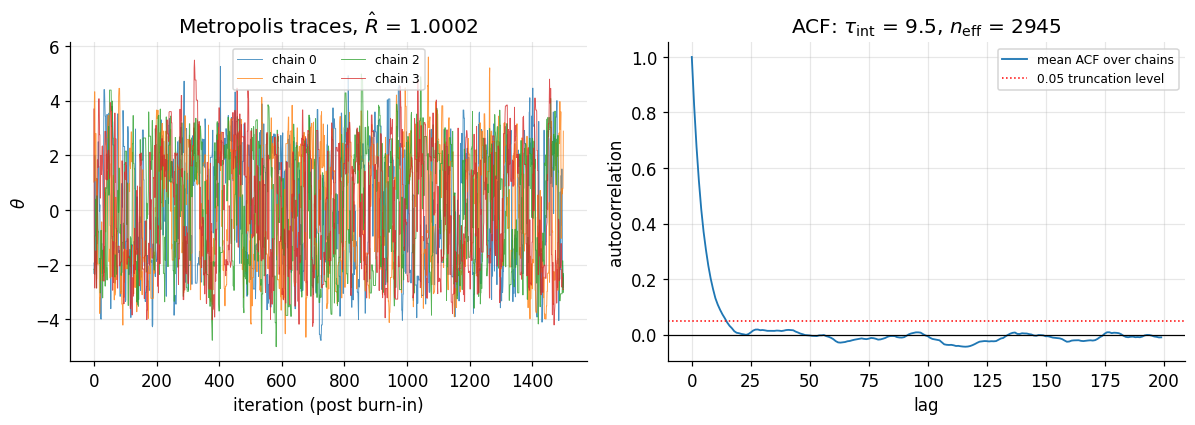

In [7]:
def log_target(theta):
    """log of an unnormalized bimodal mixture; the normalizer cancels (Theorem 4.8)."""
    return np.logaddexp(-0.5 * (theta - 2.0) ** 2, -0.5 * (theta + 2.0) ** 2)

def run_chain(chain_rng, n_steps, step_size=2.0, start=0.0):
    theta, log_p = start, log_target(start)
    chain = np.empty(n_steps)
    accepted = 0
    for i in range(n_steps):
        prop = theta + chain_rng.normal(0.0, step_size)
        log_p_prop = log_target(prop)
        if np.log(chain_rng.uniform()) < log_p_prop - log_p:   # symmetric proposal: q cancels
            theta, log_p, accepted = prop, log_p_prop, accepted + 1
        chain[i] = theta
    return chain, accepted / n_steps

n_steps, n_chains, burn = 8000, 4, 1000
chains, acc = zip(*[run_chain(np.random.default_rng(100 + s), n_steps) for s in range(n_chains)])
chains = np.stack(chains)
post_burn = chains[:, burn:]
m_draws = post_burn.shape[1]

W = post_burn.var(axis=1, ddof=1).mean()
B_over_n = post_burn.mean(axis=1).var(ddof=1)
var_hat = (1 - 1 / m_draws) * W + B_over_n
r_hat = np.sqrt(var_hat / W)

def autocorr(x, max_lag=200):
    x = x - x.mean()
    ac = np.correlate(x, x, mode="full")[len(x) - 1:]
    return (ac / ac[0])[:max_lag]

acf = np.mean([autocorr(c) for c in post_burn], axis=0)
cut = np.argmax(acf < 0.05) if np.any(acf < 0.05) else len(acf)
tau_int = 1.0 + 2.0 * acf[1:cut].sum()
n_eff = n_chains * m_draws / tau_int

print(f"acceptance rate per chain : {np.round(acc, 3)}")
print(f"pooled posterior mean     : {post_burn.mean():+.4f}   (target is symmetric about 0)")
print(f"pooled posterior sd       : {post_burn.std(ddof=1):.4f}  (exact value for this mixture: {np.sqrt(5.0):.4f})")
print(f"R-hat across {n_chains} chains   : {r_hat:.4f}   (values above ~1.01 indicate non-convergence)")
print(f"integrated autocorr. time : {tau_int:.2f} draws")
print(f"effective sample size     : {n_eff:.0f} out of {n_chains * m_draws} raw draws")
assert abs(post_burn.mean()) < 0.15 and r_hat < 1.02

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
for c in range(n_chains):
    axes[0].plot(post_burn[c, :1500], lw=0.6, alpha=0.8, label=f"chain {c}")
axes[0].set_xlabel("iteration (post burn-in)")
axes[0].set_ylabel(r"$\theta$")
axes[0].set_title(fr"Metropolis traces, $\hat R$ = {r_hat:.4f}")
axes[0].legend(fontsize=8, ncol=2)
axes[1].plot(np.arange(len(acf)), acf, lw=1.2, label="mean ACF over chains")
axes[1].axhline(0.0, color="k", lw=0.8)
axes[1].axhline(0.05, color="r", ls=":", lw=1.0, label="0.05 truncation level")
axes[1].set_xlabel("lag")
axes[1].set_ylabel("autocorrelation")
axes[1].set_title(fr"ACF: $\tau_{{\rm int}}$ = {tau_int:.1f}, $n_{{\rm eff}}$ = {n_eff:.0f}")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

All four chains cross between the two modes, so $\hat R$ sits at $1.00$ and the between-chain variance carries no extra information — the diagnostic is doing its job of certifying that the chains agree with each other as well as with themselves. The pooled mean is near $0$ and the pooled standard deviation matches the mixture's exact $\sqrt{5}$. The autocorrelation function shows the real cost of MCMC: the integrated autocorrelation time is well above $1$, so tens of thousands of raw draws are worth only a few thousand independent ones. Reporting a posterior summary without $n_{\text{eff}}$ is reporting an unstated Monte Carlo error.

**(c) Counterexample: drop the prior-positivity hypothesis.** Theorem 4.11 assumes $\tau_0^2\gt0$, and Theorem 4.10 assumes the prior density is continuous and strictly positive at $\theta_0$. The cell below breaks that hypothesis in the mildest possible way — a proper, smooth prior supported on $[1,\infty)$ while the truth is $\theta_0 = 0$ — and tracks what happens as $n$ grows over three decades. Everything else about the model is unchanged.

In [8]:
sigma_c, theta0_c, lo_c = 1.0, 0.0, 1.0
prior_loc, prior_scale = 2.0, 1.0     # N(2,1) truncated to [1, inf): proper, smooth, and
                                      # strictly positive on its support, but zero at theta_0 = 0.

def truncated_posterior(n, xbar):
    """Exact posterior for a N(2,1) prior truncated to [1,inf): truncation survives conjugacy."""
    tau_n2 = 1.0 / (1.0 / prior_scale**2 + n / sigma_c**2)
    mu_n = tau_n2 * (prior_loc / prior_scale**2 + n * xbar / sigma_c**2)
    sd_n = np.sqrt(tau_n2)
    return stats.truncnorm((lo_c - mu_n) / sd_n, np.inf, loc=mu_n, scale=sd_n)

print("     n     posterior mean   posterior sd       MLE     TV to N(MLE, 1/(nI))   prior mass near truth")
for n in [10, 100, 1000, 10000]:
    xbar = theta0_c + rng.normal(0.0, sigma_c / np.sqrt(n))
    post_c = truncated_posterior(n, xbar)
    targ_c = stats.norm(xbar, sigma_c / np.sqrt(n))
    gap = lambda t: 0.5 * abs(post_c.pdf(t) - targ_c.pdf(t))
    lo_i = min(lo_c, xbar - 12 * sigma_c / np.sqrt(n))
    hi_i = max(lo_c + 12 * post_c.std(), xbar + 12 * sigma_c / np.sqrt(n))
    tv_c = integrate.quad(gap, lo_i, lo_c, limit=400)[0] + integrate.quad(gap, lo_c, hi_i, limit=400)[0]
    prior_law = stats.truncnorm((lo_c - prior_loc) / prior_scale, np.inf, loc=prior_loc, scale=prior_scale)
    near = prior_law.cdf(theta0_c + 0.5) - prior_law.cdf(theta0_c - 0.5)   # prior mass around the truth
    print(f"{n:>7}   {post_c.mean():>13.5f}   {post_c.std():>12.5f}   {xbar:>8.4f}   {tv_c:>19.4f}   {near:>19.3f}")
    assert near == 0.0

print("\nThe posterior mean stalls at the truncation boundary 1.0 instead of approaching theta0 = 0,")
print("its spread collapses to zero around the WRONG value, and the total-variation distance to")
print("N(MLE, 1/(nI)) rises to 1 rather than falling: Bernstein-von Mises fails outright.")
print("Prior mass within 0.5 of the truth is exactly 0.000 -- Cromwell's rule, and precisely why")
print("Theorem 4.10 and Theorem 4.11 require a prior that is strictly positive at theta_0.")

     n     posterior mean   posterior sd       MLE     TV to N(MLE, 1/(nI))   prior mass near truth
     10         1.16314        0.13767     0.5943                0.9002                 0.000
    100         1.00849        0.00843    -0.1713                1.0000                 0.000
   1000         1.00099        0.00099    -0.0045                1.0000                 0.000
  10000         1.00010        0.00010     0.0034                1.0000                 0.000

The posterior mean stalls at the truncation boundary 1.0 instead of approaching theta0 = 0,
its spread collapses to zero around the WRONG value, and the total-variation distance to
N(MLE, 1/(nI)) rises to 1 rather than falling: Bernstein-von Mises fails outright.
Prior mass within 0.5 of the truth is exactly 0.000 -- Cromwell's rule, and precisely why
Theorem 4.10 and Theorem 4.11 require a prior that is strictly positive at theta_0.


The failure is not gradual: no amount of data recovers a hypothesis the prior declared impossible. This is the sharpest practical warning in the module, and it is not exotic — hard parameter bounds, priors truncated for "physical plausibility", and point-mass model priors all impose exactly this structure. The diagnostic is cheap: check that the prior assigns non-negligible mass to every value the data could plausibly support before running anything.

**Where the Laplace approximation fails.** Row 2 of the table in Section 7.1 calls Laplace "asymptotically exact; misses skew". The cell below fits the Laplace approximation — a Gaussian at the mode with variance $\left[-\left.\frac{d^2}{d\lambda^2}\ln p(\lambda\mid x)\right\vert_{\hat\lambda}\right]^{-1}$ — to the Gamma–Poisson posterior of Example 6.3 at three sample sizes, and reports the total-variation error against the exact posterior.

  posterior         mode     exact mean   Laplace mean   TV(exact, Laplace)   P(lambda<0) under Laplace
  Gamma(   6,  4)    1.2500       1.5000         1.2500               0.1120                    0.01267
  Gamma(  24, 16)    1.4375       1.5000         1.4375               0.0556                    0.00000
  Gamma(  96, 64)    1.4844       1.5000         1.4844               0.0273                    0.00000


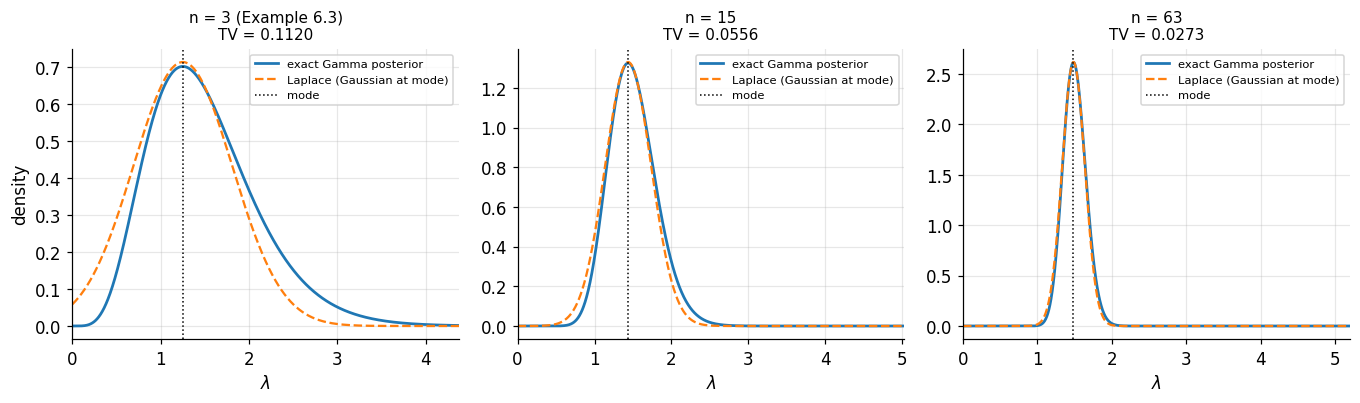

In [9]:
def laplace_vs_exact(a_post, b_post, span=(1e-6, 12.0), npts=6001):
    """Laplace fit at the mode of a Gamma(a,b) posterior, and the exact posterior."""
    mode = (a_post - 1.0) / b_post                                  # requires a_post > 1
    curvature = (a_post - 1.0) / mode**2                            # -d^2/dlam^2 log-density at mode
    lap = stats.norm(mode, np.sqrt(1.0 / curvature))
    lam = np.linspace(*span, npts)
    exact_pdf = stats.gamma.pdf(lam, a_post, scale=1.0 / b_post)
    tv = 0.5 * integrate.simpson(np.abs(exact_pdf - lap.pdf(lam)), x=lam)
    return lam, exact_pdf, lap, tv, mode

settings = [(6.0, 4.0, "n = 3 (Example 6.3)"), (24.0, 16.0, "n = 15"), (96.0, 64.0, "n = 63")]
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), sharey=False)
print("  posterior         mode     exact mean   Laplace mean   TV(exact, Laplace)   P(lambda<0) under Laplace")
for ax, (a_post, b_post, label) in zip(axes, settings):
    lam, exact_pdf, lap, tv, mode = laplace_vs_exact(a_post, b_post)
    ax.plot(lam, exact_pdf, lw=1.8, label="exact Gamma posterior")
    ax.plot(lam, lap.pdf(lam), lw=1.5, ls="--", label="Laplace (Gaussian at mode)")
    ax.axvline(mode, color="k", ls=":", lw=1.0, label="mode")
    ax.set_xlim(0.0, min(6.0, mode * 3.5))
    ax.set_xlabel(r"$\lambda$")
    ax.set_title(f"{label}\nTV = {tv:.4f}", fontsize=10)
    ax.legend(fontsize=7.5)
    print(f"  Gamma({a_post:>4.0f},{b_post:>3.0f})   {mode:>7.4f}   {a_post/b_post:>10.4f}   {mode:>12.4f}   "
          f"{tv:>18.4f}   {lap.cdf(0.0):>24.5f}")
axes[0].set_ylabel("density")
fig.tight_layout()
plt.show()

The Laplace fit improves exactly as Theorem 4.10 says it must, with the total-variation error falling roughly like $n^{-1/2}$, but at small $n$ it makes two specific errors: it centres on the mode rather than the mean, understating a right-skewed posterior, and it puts non-negligible mass on $\lambda\lt0$, a value the model forbids. Both defects vanish asymptotically and both matter in exactly the small-data regime where a Bayesian analysis was worth doing.

**Lindley's paradox, and the mean-field bias.** Two claims from earlier sections are quantified together. First, the Occam factor in Definition 3.8: with $\bar x\sim\mathcal{N}(\theta,\sigma^2/n)$, $M_0:\theta=0$ against $M_1:\theta\sim\mathcal{N}(0,\tau^2)$ gives $\operatorname{BF}_{01} = \sqrt{1+n\tau^2/\sigma^2}\,\exp\left(-\frac{z^2}{2}\cdot\frac{\tau^2}{\tau^2+\sigma^2/n}\right)$, which at fixed $z = 1.96$ — a fixed frequentist $p = 0.05$ — grows without bound in $n$. Second, the too-narrow bias asserted in Proof 5.8: for a bivariate Gaussian posterior with correlation $\rho$, the mean-field optimum has marginal variance $(1-\rho^2)$ times the true one.

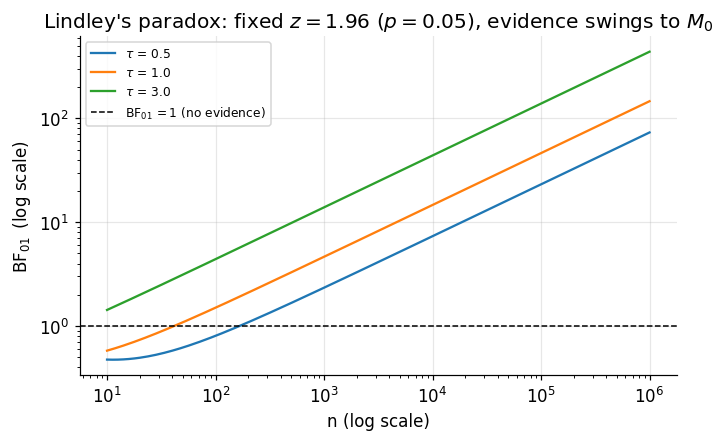

n =       100   p-value = 0.05 always   BF_01 =     1.50  -> odds 1.5:1 in favour of the null
n =     10000   p-value = 0.05 always   BF_01 =    14.65  -> odds 14.7:1 in favour of the null
n =   1000000   p-value = 0.05 always   BF_01 =   146.49  -> odds 146.5:1 in favour of the null

Mean-field VI on a bivariate normal posterior (Proof 5.8):
   rho     true marginal var    mean-field var    ratio    predicted 1-rho^2
  0.00              1.0000            1.0000    1.000              1.0000
  0.50              1.0000            0.7500    0.750              0.7500
  0.90              1.0000            0.1900    0.190              0.1900
  0.99              1.0000            0.0199    0.020              0.0199


In [10]:
# --- Lindley's paradox as a curve ------------------------------------------
z_fixed, sigma_l = 1.96, 1.0
n_l = np.logspace(1, 6, 200)
fig, ax = plt.subplots()
for tau_l in [0.5, 1.0, 3.0]:
    v = sigma_l**2 / n_l
    bf01 = np.sqrt(1.0 + tau_l**2 / v) * np.exp(-0.5 * z_fixed**2 * tau_l**2 / (tau_l**2 + v))
    ax.plot(n_l, bf01, label=fr"$\tau$ = {tau_l}")
ax.axhline(1.0, color="k", lw=1.0, ls="--", label=r"$\operatorname{BF}_{01}=1$ (no evidence)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n (log scale)")
ax.set_ylabel(r"$\operatorname{BF}_{01}$ (log scale)")
ax.set_title(r"Lindley's paradox: fixed $z=1.96$ ($p=0.05$), evidence swings to $M_0$")
ax.legend(fontsize=8)
plt.show()

for n_pt in [1e2, 1e4, 1e6]:
    v = sigma_l**2 / n_pt
    bf = np.sqrt(1.0 + 1.0 / v) * np.exp(-0.5 * z_fixed**2 * 1.0 / (1.0 + v))
    print(f"n = {n_pt:>9.0f}   p-value = 0.05 always   BF_01 = {bf:8.2f}  -> odds {bf:.1f}:1 in favour of the null")
assert np.sqrt(1 + 1e4) * np.exp(-0.5 * 1.96**2 / (1 + 1e-4)) > 14.0

# --- mean-field variational bias on a correlated 2-D Gaussian --------------
print("\nMean-field VI on a bivariate normal posterior (Proof 5.8):")
print("   rho     true marginal var    mean-field var    ratio    predicted 1-rho^2")
for rho in [0.0, 0.5, 0.9, 0.99]:
    Sigma = np.array([[1.0, rho], [rho, 1.0]])
    Lambda = np.linalg.inv(Sigma)
    mf_var = 1.0 / np.diag(Lambda)            # coordinate-ascent fixed point: precision = Lambda_jj
    print(f"  {rho:4.2f}   {Sigma[0,0]:>17.4f}   {mf_var[0]:>15.4f}   {mf_var[0]/Sigma[0,0]:>6.3f}   {1-rho**2:>17.4f}")
    assert np.allclose(mf_var, 1.0 - rho**2)

At $n=10^4$ a result that a fixed-$\alpha$ test rejects at exactly $p = 0.05$ is favoured about $15{:}1$ *for* the null by the Bayes factor, and the gap widens with $n$ and with the prior width $\tau$ — the $\tau$-dependence is why point-null Bayes factors are never prior-insensitive, even asymptotically. The mean-field table confirms Proof 5.8 exactly: at $\rho = 0.9$ the variational posterior reports a marginal variance $19\%$ of the truth, so its $95\%$ credible intervals are less than half the correct width. Variational uncertainty is a lower bound on uncertainty, never an estimate of it.

## 8. Applications

### 8.1 Machine learning

- **Bayesian neural networks and deep ensembles.** A prior over weights plus an approximate posterior (Laplace with a Kronecker-factored Fisher, SWAG, or MC-dropout) yields calibrated predictive uncertainty; deep ensembles are a crude but effective posterior sample. The quantity that makes them useful is the epistemic term of Theorem 4.5.
- **Variational autoencoders.** The ELBO of Theorem 4.7 *is* the training objective; the encoder is an amortized posterior $q_\phi(z\mid x)$ and the reparameterization trick makes the bound differentiable. The systematic narrowness measured in Section 7 is why VAE samples are blurry.
- **Gaussian processes.** Exact Bayesian inference over functions: the posterior mean is a kernel-weighted interpolation and the posterior variance grows away from the data, which is what drives Bayesian optimization's acquisition functions.
- **Thompson sampling.** For bandits and A/B tests, draw $\theta\sim p(\theta\mid x)$ and act greedily; the exploration rate is generated by posterior width alone, with no tuning constant, and the regret is near-optimal.
- **Hierarchical models and partial pooling.** Theorem 4.6 is the statistical content of multi-task learning and of every "shrink small-sample rankings" rule that works.
- **Probabilistic programming.** Stan, PyMC, NumPyro and Pyro turn a generative program into inference by HMC/NUTS or a variational engine; Theorem 4.2, Theorem 4.7 and Theorem 4.8 are the machinery underneath.

### 8.2 Physics and engineering

- **Kalman filtering and state estimation.** The measurement update is exactly the Normal–Normal step of Proof 5.3 with precisions adding; the prediction step propagates the prior through the dynamics. GPS, inertial navigation and spacecraft attitude estimation are recursive Bayesian inference in production.
- **Gravitational-wave astronomy.** LIGO parameter estimation samples posteriors over masses, spins and sky location with MCMC and nested sampling; detection claims are Bayes factors (Definition 3.8) between signal and noise-only models.
- **Cosmological parameter estimation.** CMB and large-scale-structure analyses report posteriors over $\Omega_m$, $H_0$ and $\sigma_8$ with explicit priors, and tensions between datasets are diagnosed by comparing posteriors rather than point estimates.
- **Inverse problems and tomography.** Reconstruction from projections is ill-posed; a prior (smoothness, sparsity, total variation) selects among the infinitely many data-consistent solutions, and the posterior says which features are actually resolved.
- **Combining measurements and experimental design.** Inverse-variance weighting is the Normal–Normal update; sequential Bayesian design chooses the next measurement to maximize expected information gain, i.e. expected KL divergence between prior and posterior.
- **Reliability and rare-event risk.** With zero observed failures the MLE is $0$; a Gamma or Beta prior yields a finite failure-rate posterior with honest upper credible bounds — the standard in nuclear and aerospace safety analysis, and a direct use of Proof 5.4.

## 9. Key Takeaways

1. If $(\theta,x)$ has a joint density and $0\lt p(x)\lt\infty$, then $p(\theta\mid x)\propto p(x\mid\theta)p(\theta)$, and under conditional independence batch and sequential updating agree exactly (Theorem 4.1).
2. For an exponential-family likelihood with an integrable conjugate prior, updating is the addition $(\chi,\nu)\mapsto\left(\chi+\sum_i T(x_i),\ \nu+n\right)$ — the prior is literally $\nu$ pseudo-observations (Theorem 4.2).
3. Given a finite second moment the squared-loss Bayes action is the posterior mean; a finite first moment gives the median for absolute loss and the $\frac{c_u}{c_o+c_u}$-quantile for pinball loss; a continuous bounded density gives the mode as the $0$–$1$ limit (Theorem 4.4).
4. When $\tilde x \perp x \mid \theta$ with finite second moments, predictive variance splits into aleatoric $E\left[\operatorname{Var}(\tilde x\mid\theta)\mid x\right]$ plus epistemic $\operatorname{Var}\left(E[\tilde x\mid\theta]\mid x\right)$, and plug-in prediction deletes the second (Theorem 4.5).
5. In a two-level Normal model with known $\sigma_j^2$ and $\tau^2\gt0$, the group posterior mean is $(1-B_j)y_j+B_j\mu$ with $B_j=\sigma_j^2/(\sigma_j^2+\tau^2)$, and the marginal $y_j\sim\mathcal{N}(\mu,\sigma_j^2+\tau^2)$ is what makes $\tau^2$ estimable (Theorem 4.6).
6. For any $q\ll p(\cdot\mid x)$ with finite log-expectations, $\ln p(x) = \mathcal{L}(q)+D_{\mathrm{KL}}\left(q\parallel p(\cdot\mid x)\right)$, so maximizing the ELBO minimizes a divergence whose direction forces mean-field posteriors to be too narrow — by the factor $1-\rho^2$ in the Gaussian case (Theorem 4.7, Proof 5.8).
7. Metropolis–Hastings satisfies detailed balance for any proposal because the normalizer cancels in the acceptance ratio; irreducibility and aperiodicity then give ergodic convergence, and Gibbs is the special case with acceptance $1$ under conditional conjugacy (Theorem 4.8, Corollary 4.9).
8. Under differentiability in quadratic mean, non-singular $I(\theta_0)$, a separating test sequence, interior $\theta_0$, fixed $d$, and a prior continuous and positive at $\theta_0$, the rescaled posterior converges in total variation to $\mathcal{N}\left(0,I(\theta_0)^{-1}\right)$; in the Gaussian location model the posterior mean forgets the prior at rate $n^{-1}$ while the total-variation distance closes at rate $n^{-1/2}$, and a prior that vanishes near $\theta_0$ destroys the conclusion entirely (Theorem 4.10, Theorem 4.11).

## 10. References

| Source | Chapters / Sections | Coverage |
|---|---|---|
| Gelman, Carlin, Stern, Dunson, Vehtari & Rubin, *Bayesian Data Analysis*, 3rd ed. | Ch. 1–5 (conjugate models), Ch. 5 (hierarchical), Ch. 6 (predictive checks), Ch. 11–12 (MCMC) | The standard reference for everything in Sections 3, 4 and 7. |
| van der Vaart, *Asymptotic Statistics* (1998) | §10.2, Theorem 10.1, p. 141 | Bernstein–von Mises at full rigour; the source cited by Theorem 4.10. |
| Wasserman, *All of Statistics* | Ch. 11 | Compact, critical comparison of Bayesian and frequentist inference. |
| Casella & Berger, *Statistical Inference*, 2nd ed. | §7.2.3, §7.3.4 | Bayes estimators and decision-theoretic risk; the background to Theorem 4.4. |
| Robert, *The Bayesian Choice*, 2nd ed. | Ch. 2–4 | Decision theory, noninformative priors, admissibility and the complete class theorem. |
| Bishop, *Pattern Recognition and Machine Learning* | Ch. 2–3 (conjugacy, Bayesian linear regression), Ch. 10 (variational inference) | The machine-learning reading of Theorem 4.2 and Theorem 4.7. |
| Murphy, *Probabilistic Machine Learning: Advanced Topics* (2023) | Ch. 3–4, 7, 12 | Modern algorithmic treatment: MCMC, variational inference, Bayesian deep learning. |
| MacKay, *Information Theory, Inference, and Learning Algorithms* | Ch. 3, 28 (Occam's razor and evidence), Ch. 29–30 (Monte Carlo) | The clearest account of why the evidence penalizes flexibility. |
| Robert & Casella, *Monte Carlo Statistical Methods*, 2nd ed. | Ch. 6–7, 10 | Metropolis–Hastings and Gibbs with the ergodic theory behind Theorem 4.8. |
| Rasmussen & Williams, *Gaussian Processes for Machine Learning* | Ch. 2–5 | Exact Bayesian inference over functions. |
| Cover & Thomas, *Elements of Information Theory*, 2nd ed. | §11.6 (Pinsker's inequality), §2.3 (KL divergence) | The inequality used in Step 5 of Proof 5.10. |

**Reading path.** Gelman et al. Ch. 1–3 for conjugate models and the Bayesian workflow; MacKay Ch. 28 for evidence and Occam's razor; Bishop Ch. 10 for variational inference; Robert & Casella Ch. 6–7 for the sampler theory; and van der Vaart Ch. 10 for the asymptotic bridge back to [maximum likelihood and MAP estimation](../09_maximum_likelihood_and_map_estimation/).